In [1]:
import pandas as pd
import numpy as np

In [2]:
A_df = pd.read_csv("data/A.csv", header=None)
B_df = pd.read_csv("data/B.csv", header=None)
C_df = pd.read_csv("data/C.csv", header=None)

# Convert all string-looking numbers to floats
A = A_df.apply(pd.to_numeric, errors='coerce').values
B = B_df.apply(pd.to_numeric, errors='coerce').values
C = C_df.apply(pd.to_numeric, errors='coerce').values

In [3]:
A_index_df = pd.read_csv("data/index_A.csv")
B_index_df = pd.read_csv("data/index_B.csv")
C_index_df = pd.read_csv("data/index_C.csv")

## Remove Transporation

In [4]:
A_transport_df = pd.read_csv("data/Transportation_A.csv")

In [5]:
# create a dict mapping each provider name to all its indices in A_index_df
mapping = A_index_df.groupby('provider name')['index'].apply(list)

# build a single flat list of all matching indices for the foreground processes
matched_indices_transport = [
    idx
    for name in A_transport_df['provider name']
    if name in mapping
    for idx in mapping[name]
]

In [6]:
import numpy as np

# matched_indices_transport is the list of indices to remove
to_drop = np.array(sorted(set(matched_indices_transport), key=int))

# 1) Remove from A_index_df
mask_keep = ~A_index_df['index'].isin(to_drop)
A_index_df = A_index_df.loc[mask_keep].copy()

# 2) Remove corresponding rows and columns from A
A = np.delete(A, to_drop, axis=0)  # remove rows
A = np.delete(A, to_drop, axis=1)  # remove columns

# 3) Remove the same columns from B (keep rows)
B = np.delete(B, to_drop, axis=1)

# 4) Reset the index column in A_index_df
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

## Remove and aggregate Electricity

In [7]:
A_elec_df = pd.read_csv("data/Electricity_A.csv")

In [8]:
# Inputs assumed:
# A : numeric numpy array (rows x cols)
# A_index_df : DataFrame with columns ["index", "provider name", "flow name", ...]
# A_elec_df : DataFrame with column ["provider name"] listing all electricity providers
# The indices in A_index_df["index"] align with both row and column positions of A.

# 0) Build the set of electricity provider names
elec_names = set(A_elec_df['provider name'].dropna().astype(str).unique())

# 1) Find their indices in A_index_df
elec_idx = A_index_df.loc[A_index_df['provider name'].astype(str).isin(elec_names), 'index'].astype(int).unique()

# 2) Locate the mix row index (must exist)
mix_name = "Electricity Mix (Global)"
mix_rows = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int).unique()
if len(mix_rows) == 0:
    raise ValueError("Electricity Mix (Global) not found in A_index_df['provider name'].")
mix_idx = int(mix_rows[0])

# Ensure the mix row is not purged
elec_idx_set = set(map(int, elec_idx))
elec_idx_wo_mix = sorted(elec_idx_set - {mix_idx})

# 3) Aggregate: add all electricity rows (except the mix row) into the mix row, column-wise
if len(elec_idx_wo_mix) > 0:
    # in case of NaNs
    add_block = np.nansum(A[elec_idx_wo_mix, :], axis=0)
    A[mix_idx, :] = np.nan_to_num(A[mix_idx, :]) + np.nan_to_num(add_block)

# 4) Decide what to drop
rows_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity rows except the mix row
cols_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity columns except the mix column

# (Optionally also drop the mix COLUMN; keep it if you want to retain that process as a column)
# To ALSO drop the mix column, uncomment the next line:
# cols_to_drop = np.array(sorted(elec_idx_set), dtype=int)

# 5) Remove rows/columns from A and columns from B
if rows_to_drop.size > 0:
    A = np.delete(A, rows_to_drop, axis=0)
if cols_to_drop.size > 0:
    A = np.delete(A, cols_to_drop, axis=1)
    B = np.delete(B, cols_to_drop, axis=1)

# 6) Remove the same rows from A_index_df (only rows; columns in A_index_df are metadata)
if len(elec_idx_wo_mix) > 0:
    keep_mask = ~A_index_df['index'].astype(int).isin(elec_idx_wo_mix)
    A_index_df = A_index_df.loc[keep_mask].copy()

# 7) Reset the "index" column in A_index_df to reflect 0..n-1 after deletions
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

# Remove and Aggregate Heat

In [9]:
A_heat_df = pd.read_csv("data/Heat.csv")

In [10]:
import numpy as np
import pandas as pd


def _norm_str(s):
    if pd.isna(s):
        return ""
    return str(s).strip()


def aggregate_fuel_rows_into_heat_boiler(
    A: np.ndarray,
    B: np.ndarray,
    A_index_df: pd.DataFrame,
    A_heat_df: pd.DataFrame,
    provider_col: str = "provider name",
    heat_lci_col: str = "LCI Column Index",
    heat_content_col: str = "Fuel Heat Content (MJ/unit)",
    boiler_eff_col: str = "Boiler Efficiency",
    heat_boiler_name: str = "Heat (Boiler)",
):
    # --- basic checks
    if provider_col not in A_index_df.columns:
        raise KeyError(f"'{provider_col}' not found in A_index_df.columns")
    if "index" not in A_index_df.columns:
        raise KeyError("'index' not found in A_index_df.columns")
    for c in [heat_lci_col, heat_content_col, boiler_eff_col]:
        if c not in A_heat_df.columns:
            raise KeyError(f"'{c}' not found in Heat.csv columns")

    A_n = A.shape[0]
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"A must be square, got shape {A.shape}")
    if A_index_df.shape[0] != A_n:
        raise ValueError(f"A_index_df rows ({A_index_df.shape[0]}) must match A size ({A_n})")
    if B.shape[1] != A_n:
        raise ValueError(f"B columns ({B.shape[1]}) must match A size ({A_n})")

    # --- identify "Heat (Boiler)" row index in A (old index space)
    heat_boiler_rows = A_index_df[A_index_df[provider_col].apply(_norm_str) == _norm_str(heat_boiler_name)]
    if heat_boiler_rows.empty:
        raise ValueError(f"Could not find '{heat_boiler_name}' in A_index_df['{provider_col}']")
    if len(heat_boiler_rows) > 1:
        raise ValueError(f"Found multiple '{heat_boiler_name}' rows in A_index_df; please make it unique.")
    heat_boiler_idx_old = int(pd.to_numeric(heat_boiler_rows["index"], errors="raise").iloc[0])

    # --- build a map: process name -> (heat content, boiler eff)
    heat_map = {}
    for _, r in A_heat_df.iterrows():
        name = _norm_str(r[heat_lci_col])
        if not name:
            continue
        hc = pd.to_numeric(r[heat_content_col], errors="coerce")
        be = pd.to_numeric(r[boiler_eff_col], errors="coerce")
        if pd.isna(hc) or pd.isna(be):
            continue
        heat_map[name] = (float(hc), float(be))

    # --- find matched processes: A_index provider name in Heat LCI Column Index
    provider_names = A_index_df[provider_col].apply(_norm_str)
    matched_mask = provider_names.isin(set(heat_map.keys()))

    matched_df = A_index_df.loc[matched_mask, [provider_col, "index"]].copy()
    if matched_df.empty:
        # nothing to do; return originals
        return A, B, A_index_df.copy()

    # convert matched "index" to integers (these are the row/col indices for A and col indices for B)
    matched_df["index"] = pd.to_numeric(matched_df["index"], errors="raise").astype(int)

    # do not treat Heat (Boiler) as a removable "fuel" row even if it appears in Heat.csv
    matched_df = matched_df[matched_df["index"] != heat_boiler_idx_old].copy()

    if matched_df.empty:
        # no removable matches (only Heat (Boiler) matched), so nothing to aggregate
        return A, B, A_index_df.copy()

    # --- for each matched row i: scale A[i, :] by (Fuel Heat Content / Boiler Efficiency)
    #     and then aggregate all scaled rows across columns
    agg = np.zeros(A.shape[1], dtype=float)

    for _, r in matched_df.iterrows():
        pname = _norm_str(r[provider_col])
        idx = int(r["index"])
        if idx < 0 or idx >= A.shape[0]:
            raise IndexError(f"Matched index {idx} out of bounds for A with size {A.shape[0]}")
        hc, be = heat_map[pname]
        factor = hc / be
        row_scaled = A[idx, :].astype(float) * factor
        agg += row_scaled

    # --- populate the aggregated values into the Heat (Boiler) row in A
    if heat_boiler_idx_old < 0 or heat_boiler_idx_old >= A.shape[0]:
        raise IndexError(f"Heat (Boiler) index {heat_boiler_idx_old} out of bounds for A with size {A.shape[0]}")
    A_updated = A.astype(float).copy()
    A_updated[heat_boiler_idx_old, :] = agg

    # --- NEW: force Heat (Boiler), Heat (Boiler) cell to be 1
    A_updated[heat_boiler_idx_old, heat_boiler_idx_old] = 1.0

    # --- remove the initial matched processes:
    #     - remove their rows from A_index_df
    #     - remove their rows and columns from A
    #     - remove their columns from B
    remove_indices_old = sorted(matched_df["index"].unique().tolist())

    keep_mask = np.ones(A_updated.shape[0], dtype=bool)
    keep_mask[remove_indices_old] = False
    keep_indices_old = np.where(keep_mask)[0].tolist()

    # slice A (rows + cols) and B (cols)
    A_reduced = A_updated[np.ix_(keep_indices_old, keep_indices_old)]
    B_reduced = B[:, keep_indices_old]

    # drop rows from A_index_df whose "index" is in remove list
    A_index_reduced = A_index_df.copy()
    A_index_reduced["index"] = pd.to_numeric(A_index_reduced["index"], errors="raise").astype(int)
    A_index_reduced = A_index_reduced[~A_index_reduced["index"].isin(remove_indices_old)].reset_index(drop=True)

    # renumber A_index_df index column from 0..n-1
    A_index_reduced["index"] = range(len(A_index_reduced))

    return A_reduced, B_reduced, A_index_reduced


# ---- run
A, B, A_index_df = aggregate_fuel_rows_into_heat_boiler(
    A=A,
    B=B,
    A_index_df=A_index_df,
    A_heat_df=A_heat_df
)

In [11]:
# find Heat (Boiler) index
hb_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat (Boiler)",
    "index"
].iloc[0]

# value of Heat (Boiler, Heat (Boiler)) cell
A[hb_idx, hb_idx] = 1.0

In [12]:
# row index: Heat (Boiler)
row_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat, Natural Gas",
    "index"
].iloc[0]

# column index: Heat, Natural Gas
col_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat, Natural Gas",
    "index"
].iloc[0]

A[row_idx, col_idx]

1.0

In [13]:
A_index_df.to_csv("index_A_updated.csv", index=False)

# Quality Scenario (for recycled material from mechanical)

In [14]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [15]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])

# Setting up A design

In [16]:
import numpy as np
import pandas as pd

# --- VALIDATION ---
if not isinstance(A, np.ndarray) or A.ndim != 2:
    raise ValueError("A must be a 2D NumPy array.")
n, m = A.shape
if n != m:
    raise ValueError(f"A must be square; got {A.shape}.")
need = {"index", "provider name", "flow name"}
if not need.issubset(A_index_df.columns):
    raise ValueError(f"A_index_df missing columns: {need - set(A_index_df.columns)}")

# ensure indices cover 0..n-1 uniquely
idx = pd.to_numeric(A_index_df["index"], errors="coerce").astype("Int64")
if idx.isna().any():
    raise ValueError("A_index_df['index'] contains non-integer values.")
idx_vals = idx.astype(int).to_numpy()
if len(np.unique(idx_vals)) != len(idx_vals):
    dupes = A_index_df[A_index_df.duplicated("index", keep=False)].sort_values("index")
    raise ValueError(f"Duplicate indices in A_index_df['index']:\n{dupes}")
if idx_vals.min() != 0 or idx_vals.max() != n - 1:
    raise ValueError(f"A_index_df['index'] must span 0..{n-1}.")

# --- build label arrays aligned by index ---
providers = [""] * n
flows     = [""] * n
for _, r in A_index_df.iterrows():
    i = int(r["index"])
    providers[i] = str(r["provider name"])
    flows[i]     = str(r["flow name"])

# --- assemble (no titles, no extra columns) ---
rows = []
# first two header rows (blank first two cells, then provider and flow names)
rows.append(["", ""] + providers)
rows.append(["", ""] + flows)

# numeric block with matching row labels
for i in range(n):
    rows.append([providers[i], flows[i]] + A[i, :].tolist())

final_df = pd.DataFrame(rows)

# optional: export
# final_df.to_csv("A_full_labeled_aligned_clean.csv", index=False, header=False)
A_design_df = final_df

In [17]:
decision_variables_all = pd.read_csv("data/decision_variables_dynamic.csv")
new_flow_df = pd.read_csv("data/new_flow_roadmap.csv")

In [18]:
import pandas as pd
import numpy as np

def apply_levers_add_and_populate(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Full pipeline:
      1) Remove rows from A_design_df where 'Input parameters names' has ANY activated lever == 1
         (match against the FIRST COLUMN of A_design_df; header rows 0,1 are preserved)
      2) From removed rows, capture UNIQUE PROVIDER NAMES (col 0)
      3) Map providers via new_flow_df (Process -> Flow name), dedupe flows, append blank rows:
            ["", <Flow name>, 0, 0, ...]
      4) Populate those new rows: for each matching Flow name in new_flow_df,
         write -1 (input) or +1 (output) at the column whose header (row 0) equals 'Process'.

    Expected layout for A_design_df:
      - Row 0: ['', ''] + provider headers across (cols 2..end)
      - Row 1: ['', ''] + flow headers across    (cols 2..end)
      - Row 2+: [provider_name, flow_name] + numeric (cols 2..end)

    Returns
    -------
    updated_df : pd.DataFrame
    report : dict with counts/diagnostics
    """

    # --------- validation ---------
    if A_design_df.shape[0] < 2 or A_design_df.shape[1] < 3:
        raise ValueError("A_design_df must have 2 header rows and >=3 columns.")
    if "Input parameters names" not in decision_variables_all.columns:
        raise ValueError("decision_variables_all must include 'Input parameters names'.")
    need_nf = {"Flow name", "Process", "Type of flow"}
    if not need_nf.issubset(new_flow_df.columns):
        raise ValueError(f"new_flow_df must include columns: {need_nf}")

    df  = A_design_df.copy()
    dva = decision_variables_all.copy()
    nf  = new_flow_df.copy()

    # --------- step 1: removal (by active levers) ---------
    lever_cols = [c for c in activate if c in dva.columns]
    if not lever_cols:
        raise ValueError(f"No requested levers found in decision_variables_all. Requested: {activate}")

    for c in lever_cols:
        dva[c] = pd.to_numeric(dva[c], errors="coerce").fillna(0).astype(int)

    # Key choice for matching (exact vs case-insensitive)
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        dva["_name"] = dva["Input parameters names"].map(norm)
        first_col    = df.iloc[:, 0].astype(str).map(norm)
    else:
        dva["_name"] = dva["Input parameters names"].astype(str)
        first_col    = df.iloc[:, 0].astype(str)

    to_remove_names = set(dva.loc[dva[lever_cols].sum(axis=1) > 0, "_name"])

    is_header = df.index.isin([0, 1])
    remove_mask = (~is_header) & (first_col.isin(to_remove_names))

    # capture removed providers (first column) & rows count
    removed_rows_count = int(remove_mask.sum())
    removed_providers = (
        df.loc[remove_mask, df.columns[0]].dropna().astype(str).unique().tolist()
    )
    removed_providers = sorted(set(removed_providers))

    # keep flow names too, if you want them for debugging
    removed_flows_dbg = (
        df.loc[remove_mask, df.columns[1]].dropna().astype(str).unique().tolist()
    )

    filtered_df = df.loc[~remove_mask].reset_index(drop=True)

    # --------- step 2: provider -> flow mapping, add blank rows ---------
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        provider_keys = set(map(norm, removed_providers))
        nf["_proc"] = nf["Process"].astype(str).map(norm)
        flows_to_add = nf.loc[nf["_proc"].isin(provider_keys), "Flow name"].astype(str).unique().tolist()
    else:
        provider_keys = set(map(str, removed_providers))
        flows_to_add = nf.loc[nf["Process"].astype(str).isin(provider_keys), "Flow name"].astype(str).unique().tolist()

    flows_to_add = sorted(set(flows_to_add))

    numeric_len = filtered_df.shape[1] - 2
    zero_row = [0.0] * numeric_len
    new_rows = [["", flow] + zero_row for flow in flows_to_add]

    if new_rows:
        add_df = pd.DataFrame(new_rows, columns=filtered_df.columns)
        with_added_df = pd.concat([filtered_df, add_df], ignore_index=True)
    else:
        with_added_df = filtered_df.copy()

    # --------- step 3: populate the newly added rows ---------
    # Build header map from row 0
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_keys    = [norm(h) for h in headers_pretty]
        header_to_col  = {k: 2 + i for i, k in enumerate(header_keys)}
        nf["_flow_key"] = nf["Flow name"].astype(str).map(norm)
        nf["_proc_key"] = nf["Process"].astype(str).map(norm)
        flow_key = lambda x: norm(str(x))
        proc_key = lambda x: norm(str(x))
        proc_display = lambda r: str(r["Process"])
    else:
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_to_col  = {h: 2 + i for i, h in enumerate(headers_pretty)}
        nf["_flow_key"] = nf["Flow name"].astype(str)
        nf["_proc_key"] = nf["Process"].astype(str)
        flow_key = lambda x: str(x)
        proc_key = lambda x: str(x)
        proc_display = lambda r: str(r["Process"])

    # mark the newly added rows: provider label blank & index >= 2
    first_col_after = with_added_df.iloc[:, 0].astype(str)
    is_added_row = (with_added_df.index >= 2) & (first_col_after.str.strip() == "")
    target_idxs = with_added_df.index[is_added_row].tolist()

    rows_populated = 0
    skipped_no_matches = []  # flows with no new_flow_df rows
    skipped_no_column  = []  # (process, flow) when process header not found
    skipped_bad_type   = []  # (process, flow, type)

    for i in target_idxs:
        flow_label = str(with_added_df.iat[i, 1])
        if not flow_label:
            continue

        sub = nf.loc[nf["_flow_key"] == flow_key(flow_label)]
        if sub.empty:
            skipped_no_matches.append(flow_label)
            continue

        wrote_any = False
        for _, r in sub.iterrows():
            typ = str(r["Type of flow"]).strip().casefold()
            if typ == "input":
                val = +1.0
            elif typ == "output":
                val = -1.0
            else:
                skipped_bad_type.append((proc_display(r), flow_label, r["Type of flow"]))
                continue

            # find target column (row-0 header == Process)
            col_j = header_to_col.get(proc_key(r["Process"])) if case_insensitive else header_to_col.get(r["Process"])
            if col_j is None:
                skipped_no_column.append((proc_display(r), flow_label))
                continue

            current = with_added_df.iat[i, col_j]
            if overwrite or (pd.isna(current) or float(current) == 0.0):
                with_added_df.iat[i, col_j] = val
                wrote_any = True

        if wrote_any:
            rows_populated += 1

    updated_df = with_added_df.reset_index(drop=True)

    # --------- report ---------
    report = {
        "requested_levers": lever_cols,
        "removed_rows_count": removed_rows_count,
        "removed_providers_unique": len(removed_providers),
        "removed_providers": removed_providers,
        "removed_flows_dbg": removed_flows_dbg,
        "flows_to_add": flows_to_add,
        "rows_added": len(flows_to_add),
        "rows_populated": rows_populated,
        "skipped_no_matches": skipped_no_matches,
        "skipped_no_column": skipped_no_column,
        "skipped_bad_type": skipped_bad_type,
    }
    return updated_df, report


def apply_levers_and_get_matrix(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Wrapper that:
      - runs apply_levers_add_and_populate
      - extracts the numeric submatrix from row 3, col 3 onward
      - returns: updated_df, report, numeric_subdf, numeric_matrix (np.ndarray)
    """
    updated_df, report = apply_levers_add_and_populate(
        A_design_df=A_design_df,
        decision_variables_all=decision_variables_all,
        new_flow_df=new_flow_df,
        activate=activate,
        case_insensitive=case_insensitive,
        overwrite=overwrite,
    )

    # Extract matrix from 3rd row and 3rd column onward, coerce to numeric
    A_raw = updated_df.iloc[2:, 2:]
    A_numeric = A_raw.apply(pd.to_numeric, errors="coerce")
    A_matrix = A_numeric.to_numpy()

    return updated_df, report, A_numeric, A_matrix

In [19]:
# ------------------ example call ------------------
# Options:
# Circularity
# Upstream Chemicals
# Electricity Source
# Carbon Capture
# Microplastic Treatment
# All

activated = ["Circularity", "Upstream Chemicals", "Carbon Capture", "Microplastic Treatment", "Heat Source"]
#activated = ["Base Case"]

A_design_final_df, rep, A_numeric_df, A_design_matrix = apply_levers_and_get_matrix(
    A_design_df,
    decision_variables_all,
    new_flow_df,
    activate=activated,
    case_insensitive=True,  # robust against case/space differences
    overwrite=True          # set to False to only fill zeros
)

In [20]:
n_rows, n_cols = B.shape

# -----------------------------
# Build empty dataframe with embedded headers
# size = (n_rows + 2) x (n_cols + 2)
# -----------------------------
B_design_df = pd.DataFrame(
    "",
    index=range(n_rows + 2),
    columns=range(n_cols + 2)
)

# -----------------------------
# Fill column headers (from index_A)
# row 0: provider name
# row 1: flow name
# -----------------------------
B_design_df.iloc[0, 2:] = A_index_df.sort_values("index")["provider name"].astype(str).values
B_design_df.iloc[1, 2:] = A_index_df.sort_values("index")["flow name"].astype(str).values

# -----------------------------
# Fill row headers (from index_B)
# col 0: flow name
# -----------------------------
B_design_df.iloc[2:, 0] = B_index_df.sort_values("index")["flow name"].astype(str).values

# -----------------------------
# Insert numeric B matrix
# -----------------------------
B_design_df.iloc[2:, 2:] = B

In [21]:
import numpy as np

# find the starting row index based on the second column
start_idx = A_design_final_df.index[
    A_design_final_df.iloc[:, 1] == "Ethanol (bio-mix)"
][0]

# copy second column into first column from that row to the end
A_design_final_df.iloc[start_idx:, 0] = A_design_final_df.iloc[start_idx:, 1].values

In [22]:
A_design_final_df.to_csv("results/A_design_final_df.csv", index=False)

In [23]:
B_design_df.to_csv(
    "results/B_design_final_df.csv",
    index=False,
    header=False
)

# A dynamic

In [24]:
import os
import pandas as pd

# -----------------------------
# Load inputs
# -----------------------------
a_design_df      = pd.read_csv("results/A_design_final_df.csv")
elec_mix_df      = pd.read_csv("data/electricity_mix_2025_2100_ssp1.csv")
indices_mapping  = pd.read_csv("data/iam-elec-indices.csv")

ratio_oil_ng_df  = pd.read_csv("data/ratio_oil_vs_natural_gas_2025_2100_ssp1.csv")
map_oil_ng_df    = pd.read_csv("data/oil-vs-NG-feedstock.csv")

# -----------------------------
# Prebuild lookup tables (A_design_final_df structure)
# - column provider names: row 0, cols 2:
# - row identifiers:       col 0, rows 2:
# - numeric block:         rows 2:, cols 2:
# -----------------------------
col_provider_series = a_design_df.iloc[0, 2:].astype(str)
row_provider_series = a_design_df.iloc[2:, 0].astype(str)

provider_to_col = {name: 2 + i for i, name in enumerate(col_provider_series.tolist())}
provider_to_row = {name: 2 + i for i, name in enumerate(row_provider_series.tolist())}

# -----------------------------
# Pre-index oil/NG ratio table by year
# -----------------------------
ratio_oil_ng_by_year = ratio_oil_ng_df.set_index("Year")

# -----------------------------
# Build feedstock targets from oil-vs-NG-feedstock map
# (dynamic csv name -> value in ratio table)
# Provider name -> column provider (row 0)
# Input parameters names -> row identifier (col 0)
# -----------------------------
feedstock_targets_oil_ng = []
for _, r in map_oil_ng_df.iterrows():
    dyn_name   = str(r["dynamic csv name"])
    prov_name  = str(r["Provider name"])
    input_name = str(r["Input parameters names"])

    row_idx = provider_to_row.get(input_name)
    col_idx = provider_to_col.get(prov_name)

    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_oil_ng.append((dyn_name, row_idx, col_idx))

# -----------------------------
# Generate per-year dataframes
# -----------------------------
yearly_dataframes = {}

for _, year_row in elec_mix_df.iterrows():
    year = int(year_row["Year"])
    df_year = a_design_df.copy()

    # (a) Electricity mix updates
    for _, m in indices_mapping.iterrows():
        iam_source   = str(m["IAM Index"])
        col_provider = str(m["LCI Column Index"])
        row_provider = str(m["LCI Row Index"])

        if iam_source not in elec_mix_df.columns:
            continue

        r = provider_to_row.get(row_provider)
        c = provider_to_col.get(col_provider)

        if (r is None) or (c is None):
            continue

        v = year_row[iam_source]
        if pd.isna(v):
            continue

        df_year.iat[r, c] = -abs(float(v)) / 100.0  # percent -> fraction, negative input

    # (b) Oil vs Natural Gas updates (from ratio table for this year)
    if year in ratio_oil_ng_by_year.index:
        r_year = ratio_oil_ng_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_oil_ng:
            if dyn_name in r_year.index and pd.notna(r_year[dyn_name]):
                df_year.iat[r_idx, c_idx] = -abs(float(r_year[dyn_name]))  # negative input

    yearly_dataframes[year] = df_year

# -----------------------------
# Save outputs
# -----------------------------
outdir = "results/Technology Matrix for each year"
os.makedirs(outdir, exist_ok=True)

for year, df in yearly_dataframes.items():
    df.to_csv(f"{outdir}/A_design_{year}.csv", index=False, header=False)

# B dynamic

In [25]:
import os
import pandas as pd

# -----------------------------
# Load inputs
# -----------------------------
B_design_df = pd.read_csv("results/B_design_final_df.csv", header=None, low_memory=False)
A_design_df = pd.read_csv("results/A_design_final_df.csv", low_memory=False)

bio_map_df  = pd.read_csv("data/biogenic-landuse-carbon.csv")
land_df     = pd.read_csv("data/land-use-emissions_annual_2025_2100.csv")

# -----------------------------
# Lookups for B_design_final_df (handle duplicates)
# - providers for columns: row 0, cols 2:
# - flows for rows:        col 0, rows 2:
# -----------------------------
B_col_providers = B_design_df.iloc[0, 2:].astype(str)
B_row_flows     = B_design_df.iloc[2:, 0].astype(str)

# name -> list of column indices
provider_to_cols_B = {}
for i, name in enumerate(B_col_providers.tolist()):
    provider_to_cols_B.setdefault(name, []).append(2 + i)

# flows are usually unique; but we can make it robust too:
flow_to_rows_B = {}
for i, name in enumerate(B_row_flows.tolist()):
    flow_to_rows_B.setdefault(name, []).append(2 + i)

# -----------------------------
# Lookups for A_design_final_df (both axes are providers; handle duplicates)
# - providers for columns: row 0, cols 2:
# - providers for rows:    col 0, rows 2:
# -----------------------------
A_col_providers = A_design_df.iloc[0, 2:].astype(str)
A_row_providers = A_design_df.iloc[2:, 0].astype(str)

provider_to_cols_A = {}
for i, name in enumerate(A_col_providers.tolist()):
    provider_to_cols_A.setdefault(name, []).append(2 + i)

provider_to_rows_A = {}
for i, name in enumerate(A_row_providers.tolist()):
    provider_to_rows_A.setdefault(name, []).append(2 + i)

def A_diag_abs(provider_name: str) -> float:
    """
    If duplicates exist, return abs(A[r,c]) for the first matching diagonal pair.
    (You can change this to mean/max if you prefer.)
    """
    rows = provider_to_rows_A.get(provider_name, [])
    cols = provider_to_cols_A.get(provider_name, [])
    if not rows or not cols:
        return 1.0

    # pick first pair (or you can loop all pairs)
    r = rows[0]
    c = cols[0]
    v = A_design_df.iat[r, c]
    return abs(float(v)) if pd.notna(v) else 1.0

# -----------------------------
# SSP1 land-use emissions by year
# -----------------------------
ssp1_series = (
    land_df.loc[land_df["Scenario"].astype(str).str.upper() == "SSP1", ["Year", "Value"]]
    .assign(Year=lambda d: d["Year"].astype(int))
    .set_index("Year")["Value"]
)

# -----------------------------
# Build B dataframe for each year
# Update all duplicate provider columns in B (and all duplicate flow rows if they exist)
# -----------------------------
years = list(range(2025, 2101))
B_yearly = {}

for y in years:
    df_y = B_design_df.copy()

    if y not in ssp1_series.index:
        B_yearly[y] = df_y
        continue

    land_val = float(ssp1_series.loc[y])

    for _, r in bio_map_df.iterrows():
        flow_name = str(r["Flow"])
        prov_name = str(r["Provider"])

        row_list = flow_to_rows_B.get(flow_name, [])
        col_list = provider_to_cols_B.get(prov_name, [])

        if not row_list or not col_list:
            continue

        scale = A_diag_abs(prov_name)
        new_val = land_val * scale

        # update all duplicates
        for br in row_list:
            for bc in col_list:
                df_y.iat[br, bc] = new_val

    B_yearly[y] = df_y

# -----------------------------
# Save outputs
# -----------------------------
outdir = "results/B_matrix_for_each_year"
os.makedirs(outdir, exist_ok=True)

for y, df in B_yearly.items():
    df.to_csv(f"{outdir}/B_design_{y}.csv", index=False, header=False)

# A meta

In [26]:
import numpy as np

# numeric A_meta: dict[year] -> np.ndarray (numeric block only)
A_meta = {year: df.iloc[2:, 2:].to_numpy(dtype=float) for year, df in yearly_dataframes.items()}

# (optional) enforce full year range with base matrix if missing
years = list(range(2025, 2101))
A_base = a_design_df.iloc[2:, 2:].to_numpy(dtype=float)
for y in years:
    if y not in A_meta:
        A_meta[y] = A_base.copy()

# B meta

In [27]:
import numpy as np

# numeric B_meta: dict[year] -> np.ndarray (numeric block only)
B_meta = {year: df.iloc[2:, 2:].to_numpy(dtype=float) for year, df in B_yearly.items()}

# (optional) enforce full year range with base matrix if missing
years = list(range(2025, 2101))
B_base = B_design_df.iloc[2:, 2:].to_numpy(dtype=float)

for y in years:
    if y not in B_meta:
        B_meta[y] = B_base.copy()

# f meta

In [28]:
#f meta data
demand_df = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")
demand = dict(zip(demand_df["Year"].astype(int), demand_df["Packaging_Plastic_kg"].astype(float)))
f_meta = {}
n_A = A.shape[0]
years = range(2025, 2101)
for y in years:
    f = np.zeros(n_A)
    f[0] = demand[y]
    f_meta[y] = f

# dynamic costs

In [29]:
financial_df = pd.read_csv("data/Financial Design.csv")
foreground_s_df = pd.read_csv("data/Foreground Processes Design.csv")
search_elements_foreground = foreground_s_df['provider name'].dropna().astype(str).tolist()
search_elements_finanical = financial_df['LCI Column Index'].dropna().astype(str).tolist()
positive_s_df = pd.read_csv("data/positive_s_roadmap.csv")
search_elements_positive = positive_s_df['provider name'].dropna().astype(str).tolist()
positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
positive_s_indices = [i-1 for i in positive_s_indices]
foreground_s_indices_columns = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_foreground]
foreground_s_indices_columns = [i-1 for i in foreground_s_indices_columns]


base_case_s_df = pd.read_csv("data/Base Case.csv")
search_elements_base_case = base_case_s_df['Processes'].dropna().astype(str).tolist()
base_case_s_indices_columns = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_base_case]
base_case_s_indices_columns = [i-1 for i in base_case_s_indices_columns]

# dynamic prices

In [30]:
financial_df = pd.read_csv("data/Financial Design.csv")
financial_df['LCI Column Index'] = financial_df['LCI Column Index'].astype(str)
values_dict = {}
values_dict = (
    financial_df
    .loc[financial_df['LCI Column Index'].isin(search_elements_finanical), ['LCI Column Index', 'Value']]
    .set_index('LCI Column Index')['Value']
    .to_dict()
)
result_dict = {}

# ensure consistent string comparison
A_design_final_df.iloc[:, 0] = A_design_final_df.iloc[:, 0].astype(str)

for i, name in enumerate(A_design_final_df.iloc[:, 0]):
    if name in values_dict:
        result_dict[i - 1] = values_dict[name]

inflation_rate = 0.025
years = range(2025, 2101)

cost_2025 = result_dict  # your existing dictionary

cost_by_year = {
    (i, y): v * (1 + inflation_rate) ** (y - 2025)
    for i, v in cost_2025.items()
    for y in years
}

# variable cost ratios

In [31]:
f_voc_df = pd.read_csv("data/f_voc_every_line_use_collection.csv")

# make sure keys match
f_voc_df["Process"] = f_voc_df["Process"].astype(str)
A_design_final_df.iloc[0, :] = A_design_final_df.iloc[0, :].astype(str)

# keep only what you need, indexed by Process (so lookup is easy)
lookup = (
    f_voc_df.loc[
        f_voc_df["Process"].isin(search_elements_foreground),
        ["Process", "f_VOC_of_total_cost", "TRL", "k values", "lambda values", "L_r", "L_TRL_normal"]
    ]
    .drop_duplicates(subset=["Process"])
    .set_index("Process")
)

f_voc_dict = {}
init_trl_dict = {}
k_values_dict = {}
lambda_values_dict = {}
L_r_dict = {}
L_trl_normal_dict = {}


for i, name in enumerate(A_design_final_df.iloc[0, :].astype(str)):
    if name in lookup.index:
        idx = i - 1   # your existing indexing convention
        f_voc_dict[idx]         = lookup.at[name, "f_VOC_of_total_cost"]
        init_trl_dict[idx]       = lookup.at[name, "TRL"]
        k_values_dict[idx]       = lookup.at[name, "k values"]
        lambda_values_dict[idx] = lookup.at[name, "lambda values"]
        L_r_dict[idx] = lookup.at[name, "L_r"]
        L_trl_normal_dict[idx] = lookup.at[name, "L_TRL_normal"]

In [32]:
foreground_set = set(foreground_s_indices_columns)

new_dict_f_voc = {
    i: f_voc_dict.get(i, 0.8)
    for i in foreground_set
    if i in foreground_set
    if i in f_voc_dict or i not in f_voc_dict
}

new_dict_init_trl = {
    i: init_trl_dict.get(i, 10)
    for i in foreground_set
    if i in foreground_set
    if i in init_trl_dict or i not in init_trl_dict
}

new_dict_k_values = {
    i: k_values_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in k_values_dict or i not in k_values_dict
}


new_dict_lambda_values = {
    i: lambda_values_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in lambda_values_dict or i not in lambda_values_dict
}

new_dict_l_r_values = {
    i: L_r_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in L_r_dict or i not in L_r_dict
}

L_trl_normal_dict_values = {
    i: L_trl_normal_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in L_trl_normal_dict or i not in L_trl_normal_dict
}

In [33]:
trl_min = 1
trl_max = 10

new_dict_init_trl_norm = {
    k: (v - trl_min) / (trl_max - trl_min)
    for k, v in new_dict_init_trl.items()
}

# Optimization

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from pyomo.environ import *
from pyomo.environ import RangeSet
from pyomo.environ import value
import plotly.graph_objects as go

In [47]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, NonNegativeReals, Binary, minimize, value
)

# -----------------------
# SETTINGS
# -----------------------
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M must be a safe upper bound on s (for years where tech is allowed)
M_S = 1e20

# Optional: force "if selected => used at least once"
EPS_USE = 0.0

# Optional: tiny penalty on selecting technologies
SELECT_PENALTY = 0.0


# -----------------------
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# -----------------------
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0

# ============================================================
# PRECOMPUTE TRL*(t) AND r*(t)
# ============================================================
C_max = A_design_matrix.shape[1]

# You said set_L is your foreground process indices; we will use ONLY set_L for:
# - binaries y[j]
# - TRL gating
# - ratio evolution
# So L must be consistent with A columns.
foreground_indices = sorted([j for j in new_dict_init_trl.keys() if 1 <= j <= C_max])

# Precompute TRL allow (0/1) and r*(t)
allow_data = {}   # (j,t) -> 0/1 (TRL threshold)
ratio_data = {}   # (j,t) -> r*(t)
rd_cost_data = {} # j -> RD cost

for j in foreground_indices:
    # ---- TRL* inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))   # TRL*(2025)
    k_j    = float(new_dict_k_values.get(j, 0.0))        # k parameter

    # ---- ratio inputs
    y0_r   = float(new_dict_f_voc.get(j, 1.0))           # r*(2025)
    lam_j  = float(new_dict_lambda_values.get(j, 0.0))   # lambda parameter

    # ---- RD cost based on initial TRL integer at 2025
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # ---------- TRL*(t): your exact formula + cap at 1.0 ----------
        trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
        if trl_t > TRL_CAP:
            trl_t = TRL_CAP
        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # ---------- r*(t): your exact formula + cap at 0.8 ----------
        # If r*(2025) already >= 0.8, it never changes.
        if y0_r >= RATIO_CAP:
            r_t = y0_r
        else:
            r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
            if r_t > RATIO_CAP:
                r_t = RATIO_CAP

        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

model.set_Q = Set(initialize=positive_s_indices)

# k indices used in unit_cost
model.set_K = Set(initialize=sorted({k for (k, t) in cost_by_year.keys()}), ordered=True)

# Foreground indices (your main tech set)
model.set_L = Set(initialize=foreground_indices, ordered=True)

# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# scaling factors (can be negative in general, but we will force s>=0 for j in set_L)
model.s = Var(model.set_C, model.set_T, within=Reals)

# binary: whether tech is invested/allowed at all
model.y = Var(model.set_L, within=Binary)

# -----------------------
# CONSTRAINTS
# -----------------------
# Balance: A*s = f (year-by-year)
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# Positive scaling for subset Q (your original constraint)
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# NEW: enforce s>=0 for all foreground indices in cost (prevents negative-cost gaming)
def nonneg_foreground_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_foreground = Constraint(model.set_L, model.set_T, rule=nonneg_foreground_rule)

# Selection gate (if y[j]=0 then s[j,t]=0)
def select_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j]
model.select_gate = Constraint(model.set_L, model.set_T, rule=select_gate_rule)

# TRL gate (if allow[j,t]=0 then s[j,t]=0 even if selected)
def trl_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j] * m.allow[j, t]
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# Optional: if selected, must be used at least once (summing s since s>=0 here)
if EPS_USE and EPS_USE > 0.0:
    def must_use_rule(m, j):
        return sum(m.s[j, t] for t in m.set_T) >= EPS_USE * m.y[j]
    model.must_use = Constraint(model.set_L, rule=must_use_rule)

# -----------------------
# OBJECTIVE COEFFICIENTS
# -----------------------
# coef[j,t] = (1/r*(j,t)) * sum_k |A_meta[t][k-1, j-1]| * unit_cost[k,t]
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS

    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# -----------------------
# OBJECTIVE (NO ABS)
# -----------------------
# Operating cost + one-time RD cost (if selected)
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L)
        + (SELECT_PENALTY * sum(model.y[j] for j in model.set_L) if SELECT_PENALTY else 0.0),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)


In [52]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M upper bound on s[j,t] for foreground techs
M_S = 1e20

# Optional: force "if selected => used at least once"
EPS_USE = 0.0

# Optional: tiny penalty on selecting technologies
SELECT_PENALTY = 0.0


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# PRECOMPUTE TRL*(t) AND r*(t) USING YOUR FORMULA
# ============================================================
C_max = A_design_matrix.shape[1]

foreground_indices = sorted([j for j in new_dict_init_trl.keys() if 1 <= j <= C_max])

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # TRL* inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))  # TRL*(2025)
    k_j = float(new_dict_k_values.get(j, 0.0))

    # ratio inputs
    y0_r = float(new_dict_f_voc.get(j, 1.0))            # r*(2025)
    lam_j = float(new_dict_lambda_values.get(j, 0.0))

    # one-time R&D cost tier (based on integer TRL at 2025)
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # TRL*(t)
        trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
        if trl_t > TRL_CAP:
            trl_t = TRL_CAP
        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # r*(t)
        if y0_r >= RATIO_CAP:
            r_t = y0_r  # frozen
        else:
            r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
            if r_t > RATIO_CAP:
                r_t = RATIO_CAP
        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# SETS
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

model.set_Q = Set(initialize=positive_s_indices)
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)
model.set_L = Set(initialize=foreground_indices, ordered=True)

# PARAMETERS
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# VARIABLES
# s can be negative in general, but for technologies in set_L (TRL-changing),
# you want s to always be nonnegative.
model.s = Var(model.set_C, model.set_T, within=Reals)

# tech selection (invest)
model.y = Var(model.set_L, within=Binary)

# CONSTRAINTS
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# your existing positive subset
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# IMPORTANT: for TRL-changing technologies, enforce s >= 0 always
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# Selection gate (now one-sided is enough because s[j,t] >= 0 for j in set_L)
def select_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j]
model.select_gate = Constraint(model.set_L, model.set_T, rule=select_gate_rule)

# TRL gate (one-sided enough because s[j,t] >= 0 for j in set_L)
def trl_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j] * m.allow[j, t]
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# optional: if selected, must be used at least once (works because s>=0 on set_L)
if EPS_USE and EPS_USE > 0.0:
    def must_use_rule(m, j):
        return sum(m.s[j, t] for t in m.set_T) >= EPS_USE * m.y[j]
    model.must_use = Constraint(model.set_L, rule=must_use_rule)

# OBJECTIVE COEFFICIENTS
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS
    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# OBJECTIVE (NO ABS)
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L)
        + (SELECT_PENALTY * sum(model.y[j] for j in model.set_L) if SELECT_PENALTY else 0.0),
    sense=minimize
)

# SOLVE (example)
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)

In [56]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12 

# Big-M must be a safe upper bound on s[j,t] for foreground techs
# Do NOT make this extremely huge (e.g., 1e20) unless you want numerical issues.
M_S = 1e20


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# PRECOMPUTE TRL*(t) AND r*(t) USING YOUR FORMULA
# ============================================================
# TRL*(t) = TRL*(t0) + 1/(1 + exp(-k_j*(t-t0))) , capped at 1.0
# r*(t)   = r*(t0)   + 1/(1 + exp(-lambda_j*(t-t0))) , capped at 0.8
# If r*(t0) >= 0.8 => r* is constant forever
#
# allow[j,t] = 1 if TRL*(t) >= TRL*(TRL=8) else 0
# ============================================================
C_max = A_design_matrix.shape[1]

# Use the indices that exist in your TRL dict (consistent with A columns)
foreground_indices = sorted([j for j in new_dict_init_trl.keys() if 1 <= j <= C_max])

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # ---- TRL inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))  # TRL*(2025)
    k_j = float(new_dict_k_values.get(j, 0.0))          # k value

    # ---- Ratio inputs
    y0_r = float(new_dict_f_voc.get(j, 1.0))            # r*(2025)
    lam_j = float(new_dict_lambda_values.get(j, 0.0))   # lambda value

    # ---- RD cost tier (based on integer TRL at 2025)
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # TRL*(t)
        trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
        if trl_t > TRL_CAP:
            trl_t = TRL_CAP
        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # r*(t)
        if y0_r >= RATIO_CAP:
            r_t = y0_r  # frozen
        else:
            r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
            if r_t > RATIO_CAP:
                r_t = RATIO_CAP

        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

# Original subset requiring s>=0
model.set_Q = Set(initialize=positive_s_indices)

# k indices used in unit_cost
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)

# Foreground tech indices used for TRL + cost + selection
model.set_L = Set(initialize=foreground_indices, ordered=True)

# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# Scaling factors: general s can be negative, BUT for these tech indices (set_L),
# we enforce s >= 0 below (since you said TRL-changing techs always have positive s).
model.s = Var(model.set_C, model.set_T, within=Reals)

# Binary: invest/enable technology j
model.y = Var(model.set_L, within=Binary)

# -----------------------
# CONSTRAINTS
# -----------------------
# Balance: A*s = f
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# Positive scaling for your existing subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# TRL-changing technologies always have nonnegative scaling
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# Selection gate: if y[j]=0 => s[j,t]=0 (works because s[j,t] >= 0)
def select_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j]
model.select_gate = Constraint(model.set_L, model.set_T, rule=select_gate_rule)

# TRL gate: if allow[j,t]=0 => s[j,t]=0 (even if y[j]=1)
def trl_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j] * m.allow[j, t]
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# -----------------------
# OBJECTIVE COEFFICIENTS
# -----------------------
# coef[j,t] = (1/r*(j,t)) * sum_k |A_meta[t][k-1, j-1]| * unit_cost[k,t]
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS

    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# -----------------------
# OBJECTIVE (NO ABS)
# -----------------------
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)

In [ ]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M upper bound on s[j,t] for foreground techs
M_S = 1e20


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0

foreground_indices = sorted(list(new_dict_init_trl.keys()))

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # TRL* inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))  # TRL*(2025)
    k_j = float(new_dict_k_values.get(j, 0.0))          # k value

    # ratio inputs
    y0_r = float(new_dict_f_voc.get(j, 1.0))            # r*(2025)
    lam_j = float(new_dict_lambda_values.get(j, 0.0))   # lambda value

    # RD cost tier (based on integer TRL at 2025)
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # ---- TRL*(t)
        trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
        if trl_t > TRL_CAP:
            trl_t = TRL_CAP
        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # ---- r*(t)
        if y0_r >= RATIO_CAP:
            r_t = y0_r
        else:
            r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
            if r_t > RATIO_CAP:
                r_t = RATIO_CAP

        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

# subset requiring s>=0
model.set_Q = Set(initialize=positive_s_indices)

# k indices used in unit_cost
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)

# Foreground tech indices used for TRL + cost + selection
model.set_L = Set(initialize=foreground_indices, ordered=True)

# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# scaling factors (can be negative in general, but for TRL-changing techs you want s>=0)
model.s = Var(model.set_C, model.set_T, within=Reals)

# binary: invest/enable technology j
model.y = Var(model.set_L, within=Binary)

# -----------------------
# CONSTRAINTS
# -----------------------
# Balance: A*s = f (year-by-year)
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# s>=0 for your existing subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# TRL-changing technologies have nonnegative scaling
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# Selection gate: if y[j]=0 => s[j,t]=0 (works because s[j,t] >= 0)
def select_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j]
model.select_gate = Constraint(model.set_L, model.set_T, rule=select_gate_rule)

# TRL gate: if allow[j,t]=0 => s[j,t]=0
def trl_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j] * m.allow[j, t]
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# -----------------------
# OBJECTIVE COEFFICIENTS
# -----------------------
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS

    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# -----------------------
# OBJECTIVE (NO ABS)
# -----------------------
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)


In [63]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M upper bound on s[j,t] for foreground techs
M_S = 1e20

EPS_USE = 1

def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0

foreground_indices = sorted(list(new_dict_init_trl.keys()))

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # TRL inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))  # TRL*(2025)
    k_j = float(new_dict_k_values.get(j, 0.0))

    # ratio inputs
    y0_r = float(new_dict_f_voc.get(j, 1.0))            # r*(2025)
    lam_j = float(new_dict_lambda_values.get(j, 0.0))

    # RD cost tier (based on integer TRL at 2025)
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # ---- TRL*(t)
        if t == t0:
            trl_t = y0_trl
        else:
            trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
            if trl_t > TRL_CAP:
                trl_t = TRL_CAP
        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # ---- r*(t)
        if t == t0:
            r_t = y0_r
        else:
            if y0_r >= RATIO_CAP:
                r_t = y0_r
            else:
                r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
                if r_t > RATIO_CAP:
                    r_t = RATIO_CAP
        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# SETS
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

model.set_Q = Set(initialize=positive_s_indices)
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)
model.set_L = Set(initialize=foreground_indices, ordered=True)

# PARAMETERS
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# VARIABLES
model.s = Var(model.set_C, model.set_T, within=Reals)
model.y = Var(model.set_L, within=Binary)

# CONSTRAINTS
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# Your assumption: TRL-changing technologies always have positive s
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# If y[j]=0, force s[j,t]=0 (works because s[j,t] >= 0 on set_L)
def select_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j]
model.select_gate = Constraint(model.set_L, model.set_T, rule=select_gate_rule)

# If allow[j,t]=0, force s[j,t]=0 in that year even if y[j]=1
def trl_gate_rule(m, j, t):
    return m.s[j, t] <= M_S * m.y[j] * m.allow[j, t]
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# NEW: if y[j]=1, then technology must be used at least once somewhere
# This ensures you don't pay R&D unless it is actually used.
def must_use_if_selected_rule(m, j):
    return sum(m.s[j, t] for t in m.set_T) >= EPS_USE * m.y[j]
model.must_use_if_selected = Constraint(model.set_L, rule=must_use_if_selected_rule)

# OBJECTIVE COEFFICIENTS
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS
    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# OBJECTIVE (NO ABS)
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# SOLVE (example)
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)


ERROR: Constructing component 'balance' from data=None failed:
    KeyboardInterrupt:


KeyboardInterrupt: 

In [ ]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, NonNegativeReals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M upper bound on s[j,t] for foreground techs (keep reasonable!)
# If you set this to 1e20, you WILL get numerical issues like you saw.
M_S = 1e8


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# PRECOMPUTE TRL*(t) AND r*(t) USING YOUR FORMULA
# ============================================================
# IMPORTANT:
# - 2025 is EXACTLY your initial values (no +0.5 jump).
# - growth starts from 2026 onward.
#
# TRL*(t>2025) = TRL*(2025) + 1/(1 + exp(-k_j*(t-t0))) capped at 1.0
# r*(t>2025)   = r*(2025)   + 1/(1 + exp(-lambda_j*(t-t0))) capped at 0.8
# if r*(2025) >= 0.8 -> r* stays constant forever
#
# allow[j,t] = 1 if TRL*(t) >= cutoff else 0
# ============================================================
foreground_indices = sorted(list(new_dict_init_trl.keys()))

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # TRL inputs
    y0_trl = float(new_dict_init_trl_norm.get(j, 1.0))  # TRL*(2025)
    k_j = float(new_dict_k_values.get(j, 0.0))          # k value for TRL

    # ratio inputs
    y0_r = float(new_dict_f_voc.get(j, 1.0))            # r*(2025)
    lam_j = float(new_dict_lambda_values.get(j, 0.0))   # lambda value for ratio

    # RD cost tier based on integer TRL at 2025
    rd_cost_data[j] = rd_cost_from_trl(new_dict_init_trl.get(j, 10))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # TRL*(t)
        if t == t0:
            trl_t = y0_trl
        else:
            trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
            if trl_t > TRL_CAP:
                trl_t = TRL_CAP

        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # r*(t)
        if t == t0:
            r_t = y0_r
        else:
            if y0_r >= RATIO_CAP:
                r_t = y0_r
            else:
                r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
                if r_t > RATIO_CAP:
                    r_t = RATIO_CAP

        ratio_data[(j, t)] = max(RATIO_EPS, float(r_t))


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

# original subset requiring s>=0
model.set_Q = Set(initialize=positive_s_indices)

# k indices used in unit_cost
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)

# tech indices that have TRL/ratio dynamics + R&D cost
model.set_L = Set(initialize=foreground_indices, ordered=True)

# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# scaling factors (general)
model.s = Var(model.set_C, model.set_T, within=Reals)

# y[j] = 1 if tech j is used at least once sometime (we enforce it via z below)
model.y = Var(model.set_L, within=Binary)

# z[j,t] = 1 if tech j is used in year t
model.z = Var(model.set_L, model.set_T, within=Binary)

# -----------------------
# CONSTRAINTS
# -----------------------
# Balance: A*s = f (year-by-year)
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# Your original: s>=0 for subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# For TRL-changing technologies, you said s is always positive
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# Link usage binary z to y: if used in any year -> y must be 1
def z_implies_y_rule(m, j, t):
    return m.z[j, t] <= m.y[j]
model.z_implies_y = Constraint(model.set_L, model.set_T, rule=z_implies_y_rule)

# Force "if y=1 then used at least once" (no EPS, no numerics)
def y_implies_some_use_rule(m, j):
    return m.y[j] <= sum(m.z[j, t] for t in m.set_T)
model.y_implies_some_use = Constraint(model.set_L, rule=y_implies_some_use_rule)

# TRL gate: cannot use in a year unless allow=1
def trl_use_gate_rule(m, j, t):
    return m.z[j, t] <= m.allow[j, t]
model.trl_use_gate = Constraint(model.set_L, model.set_T, rule=trl_use_gate_rule)

# If not used in year t (z=0), then s must be 0; if z=1, then 0 <= s <= M_S.
# (One-sided is enough because s>=0 on set_L.)
def s_bound_by_use_rule(m, j, t):
    return m.s[j, t] <= M_S * m.z[j, t]
model.s_bound_by_use = Constraint(model.set_L, model.set_T, rule=s_bound_by_use_rule)

# -----------------------
# OBJECTIVE COEFFICIENTS
# -----------------------
# coef[j,t] = (1/r*(j,t)) * sum_k |A_meta[t][k-1, j-1]| * unit_cost[k,t]
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS
    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# -----------------------
# OBJECTIVE (NO ABS)
# -----------------------
# Operating cost + one-time R&D cost, but R&D is paid IFF the tech is used at least once
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)


In [68]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, NonNegativeReals, Binary, minimize, value
)

# ============================================================
# SETTINGS
# ============================================================
t0 = 2025
t_start = 2025
t_end = 2100

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M upper bound on s[j,t] for foreground techs (keep reasonable!)
# If you set this to 1e20, you WILL get numerical issues like you saw.
M_S = 1e20


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# PRECOMPUTE TRL*(t) AND r*(t) USING YOUR FORMULA
# ============================================================
# IMPORTANT:
# - 2025 is EXACTLY your initial values (no +0.5 jump).
# - growth starts from 2026 onward.
#
# TRL*(t>2025) = TRL*(2025) + 1/(1 + exp(-k_j*(t-t0))) capped at 1.0
# r*(t>2025)   = r*(2025)   + 1/(1 + exp(-lambda_j*(t-t0))) capped at 0.8
# if r*(2025) >= 0.8 -> r* stays constant forever
#
# allow[j,t] = 1 if TRL*(t) >= cutoff else 0
# ============================================================
foreground_indices = sorted(list(new_dict_init_trl.keys()))

allow_data = {}    # (j,t) -> 0/1
ratio_data = {}    # (j,t) -> r*(t)
rd_cost_data = {}  # j -> RD cost

for j in foreground_indices:
    # --- TRL inputs (always exist)
    y0_trl = float(new_dict_init_trl_norm[j])   # TRL*(2025)
    k_j    = float(new_dict_k_values[j])        # k for TRL growth

    # --- ratio inputs (always exist)
    y0_r   = float(new_dict_f_voc[j])           # r*(2025)
    lam_j  = float(new_dict_lambda_values[j])   # lambda for ratio evolution

    # --- R&D cost tier (always exist)
    rd_cost_data[j] = float(rd_cost_from_trl(new_dict_init_trl[j]))

    for t in range(t_start, t_end + 1):
        dt = float(t - t0)

        # ----------------
        # TRL*(t) (2025 fixed; evolve after 2025)
        # ----------------
        if t == t0:
            trl_t = y0_trl
        else:
            trl_t = y0_trl + 1.0 / (1.0 + math.exp(-k_j * dt))
            if trl_t > TRL_CAP:
                trl_t = TRL_CAP

        allow_data[(j, t)] = 1.0 if trl_t >= trl_norm_cutoff else 0.0

        # ----------------
        # r*(t) (2025 fixed; if already >=0.8 then frozen)
        # ----------------
        if t == t0:
            r_t = y0_r
        else:
            if y0_r >= RATIO_CAP:
                r_t = y0_r
            else:
                r_t = y0_r + 1.0 / (1.0 + math.exp(-lam_j * dt))
                if r_t > RATIO_CAP:
                    r_t = RATIO_CAP

        ratio_data[(j, t)] = max(RATIO_EPS, r_t)

# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])
model.set_R = RangeSet(1, A_design_matrix.shape[0])
model.set_T = Set(initialize=range(t_start, t_end + 1), ordered=True)

# original subset requiring s>=0
model.set_Q = Set(initialize=positive_s_indices)

# k indices used in unit_cost
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)

# tech indices that have TRL/ratio dynamics + R&D cost
model.set_L = Set(initialize=foreground_indices, ordered=True)

# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    return float(allow_data[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)

def ratio_init_rule(m, j, t):
    return float(ratio_data[(j, t)])

model.voc_ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# scaling factors (general)
model.s = Var(model.set_C, model.set_T, within=Reals)

# y[j] = 1 if tech j is used at least once sometime (we enforce it via z below)
model.y = Var(model.set_L, within=Binary)

# z[j,t] = 1 if tech j is used in year t
model.z = Var(model.set_L, model.set_T, within=Binary)

# -----------------------
# CONSTRAINTS
# -----------------------
# Balance: A*s = f (year-by-year)
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# Your original: s>=0 for subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# For TRL-changing technologies, you said s is always positive
def nonneg_trltech_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_trltech = Constraint(model.set_L, model.set_T, rule=nonneg_trltech_rule)

# Link usage binary z to y: if used in any year -> y must be 1
def z_implies_y_rule(m, j, t):
    return m.z[j, t] <= m.y[j]
model.z_implies_y = Constraint(model.set_L, model.set_T, rule=z_implies_y_rule)

# Force "if y=1 then used at least once" (no EPS, no numerics)
def y_implies_some_use_rule(m, j):
    return m.y[j] <= sum(m.z[j, t] for t in m.set_T)
model.y_implies_some_use = Constraint(model.set_L, rule=y_implies_some_use_rule)

# TRL gate: cannot use in a year unless allow=1
def trl_use_gate_rule(m, j, t):
    return m.z[j, t] <= m.allow[j, t]
model.trl_use_gate = Constraint(model.set_L, model.set_T, rule=trl_use_gate_rule)

# If not used in year t (z=0), then s must be 0; if z=1, then 0 <= s <= M_S.
# (One-sided is enough because s>=0 on set_L.)
def s_bound_by_use_rule(m, j, t):
    return m.s[j, t] <= M_S * m.z[j, t]
model.s_bound_by_use = Constraint(model.set_L, model.set_T, rule=s_bound_by_use_rule)

# -----------------------
# OBJECTIVE COEFFICIENTS
# -----------------------
# coef[j,t] = (1/r*(j,t)) * sum_k |A_meta[t][k-1, j-1]| * unit_cost[k,t]
def coef_init_rule(m, j, t):
    r_t = float(value(m.voc_ratio[j, t]))
    if abs(r_t) < RATIO_EPS:
        r_t = RATIO_EPS
    return (1.0 / r_t) * sum(
        abs(A_meta[t][k - 1, j - 1]) * float(value(m.unit_cost[k, t]))
        for k in m.set_K
    )

model.coef = Param(model.set_L, model.set_T, initialize=coef_init_rule, within=Reals, mutable=False)

# -----------------------
# OBJECTIVE (NO ABS)
# -----------------------
# Operating cost + one-time R&D cost, but R&D is paid IFF the tech is used at least once
model.obj = Objective(
    expr=
        sum(model.coef[j, t] * model.s[j, t] for t in model.set_T for j in model.set_L)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)

In [77]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, NonNegativeReals, Binary, minimize
)

# ============================================================
# USER SETTINGS
# ============================================================
t_start = 2025
t_end   = 2100
t0_calendar = 2025  # just the model start year (NOT the investment start)

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0  # TRL8 => 7/9

TRL_CAP   = 1.0
RATIO_CAP = 0.8
RATIO_EPS = 1e-12

# Big-M for s on TRL-changing technologies (must be >= max feasible s on those cols)
# You said your s can be huge; start e.g. 1e13 and adjust if needed.
M_S = 1e20


# ============================================================
# ONE-TIME R&D COST (based on initial TRL integer at 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# DEFINE TECH SET (foreground indices) AND YEAR SET
# ============================================================
# You said indices are valid; we use them directly.
techs = sorted(list(new_dict_init_trl.keys()))
years = list(range(t_start, t_end + 1))
year_to_pos = {yy: i for i, yy in enumerate(years)}  # 0..(T-1)
max_age = len(years) - 1  # maximum (t - tau) in years


# ============================================================
# PRECOMPUTE:
# 1) base_cost[j,t] = sum_k |A_meta[t][k-1,j-1]| * unit_cost[k,t]
# 2) TRL evolution as a function of "age since investment": age = 0,1,2,...
# 3) ratio evolution as a function of "age since investment"
# 4) allow_age[j,age] = 1 if TRL(age) >= cutoff else 0
# 5) coef_use[j,t,tau] = base_cost[j,t] / r_age[j,age] (so objective stays linear)
#
# IMPORTANT:
# - TRL and ratio DO NOT evolve with calendar time anymore.
# - They evolve only with "age since investment start tau".
# - If never invested, there is no tau chosen, so there is no evolution used.
# ============================================================

# ---- base_cost[j,t]
K_set = sorted({k for (k, tt) in cost_by_year.keys()})
base_cost = {}  # (j,t) -> float

for j in techs:
    for t in years:
        ssum = 0.0
        # use your same indexing convention: A_meta[t][k-1, j-1]
        for k in K_set:
            ssum += abs(A_meta[t][k - 1, j - 1]) * float(cost_by_year[(k, t)])
        base_cost[(j, t)] = float(ssum)

# ---- TRL(age) and allow_age
trl_by_age = {}     # (j,age) -> TRL* in [0,1]
allow_age = {}      # (j,age) -> 0/1

for j in techs:
    y0_trl = float(new_dict_init_trl_norm[j])   # TRL*(at investment start, age=0)
    k_j    = float(new_dict_k_values[j])        # growth speed

    for age in range(0, max_age + 1):
        if age == 0:
            trl_val = y0_trl
        else:
            trl_val = y0_trl + 1.0 / (1.0 + math.exp(-k_j * float(age)))
            if trl_val > TRL_CAP:
                trl_val = TRL_CAP

        trl_by_age[(j, age)] = float(trl_val)
        allow_age[(j, age)] = 1.0 if trl_val >= trl_norm_cutoff else 0.0

# ---- ratio(age)
ratio_by_age = {}   # (j,age) -> r* (capped at 0.8)

for j in techs:
    y0_r  = float(new_dict_f_voc[j])            # r*(at investment start, age=0)
    lam_j = float(new_dict_lambda_values[j])    # speed for ratio improvement

    for age in range(0, max_age + 1):
        if age == 0:
            r_val = y0_r
        else:
            if y0_r >= RATIO_CAP:
                r_val = y0_r
            else:
                r_val = y0_r + 1.0 / (1.0 + math.exp(-lam_j * float(age)))
                if r_val > RATIO_CAP:
                    r_val = RATIO_CAP

        if r_val < RATIO_EPS:
            r_val = RATIO_EPS

        ratio_by_age[(j, age)] = float(r_val)

# ---- one-time R&D costs
rd_cost_data = {j: float(rd_cost_from_trl(new_dict_init_trl[j])) for j in techs}

# ---- Build triple index (j, t, tau) for tau <= t, and precompute objective coef on that triple
# coef_use[(j,t,tau)] = base_cost[j,t] * (1 / ratio_by_age[j, age]) where age = t - tau
JTT = []            # list of (j,t,tau)
coef_use = {}       # (j,t,tau) -> float
allow_triple = {}   # (j,t,tau) -> 0/1 (same as allow_age[j, t-tau])

for j in techs:
    for t in years:
        for tau in years:
            if tau > t:
                break
            age = (t - tau)
            JTT.append((j, t, tau))
            allow_flag = float(allow_age[(j, age)])
            allow_triple[(j, t, tau)] = allow_flag
            coef_use[(j, t, tau)] = float(base_cost[(j, t)] / ratio_by_age[(j, age)])


# ============================================================
# BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])          # all columns/processes
model.set_R = RangeSet(1, A_design_matrix.shape[0])          # all balance rows
model.set_T = Set(initialize=years, ordered=True)            # years
model.set_K = Set(initialize=K_set, ordered=True)            # k indices

# Foreground techs (TRL-changing)
model.set_L = Set(initialize=techs, ordered=True)

# Investment start years for each tech: tau in years
model.set_TAU = Set(initialize=years, ordered=True)

# Triple index for “use of tech j in year t with investment start tau (tau<=t)”
model.set_JTT = Set(initialize=JTT, dimen=3)

# Your original nonnegativity subset
model.set_Q = Set(initialize=positive_s_indices)

# -----------------------
# PARAMETERS
# -----------------------
def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

# allow flag on triples (constant 0/1) derived from TRL(age)
def allow_triple_init(m, j, t, tau):
    return float(allow_triple[(j, t, tau)])

model.allow_triple = Param(model.set_JTT, initialize=allow_triple_init, within=Reals, mutable=False)

# objective coefficient on triples (constant)
def coef_use_init(m, j, t, tau):
    return float(coef_use[(j, t, tau)])

model.coef_use = Param(model.set_JTT, initialize=coef_use_init, within=Reals, mutable=False)

# one-time R&D cost per tech
def rd_cost_init(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# Scaling factors for ALL columns (used in balance)
model.s = Var(model.set_C, model.set_T, within=Reals)

# Investment-start decision:
# inv[j,tau] = 1 means “we start investing in tech j at year tau”
model.inv = Var(model.set_L, model.set_TAU, within=Binary)

# y[j] = 1 means “tech j is invested in (some tau chosen)”
model.y = Var(model.set_L, within=Binary)

# s_use[j,t,tau] is the amount of s[j,t] attributed to investment start tau (tau<=t)
# Nonnegative because you said TRL-changing techs always have positive s.
model.s_use = Var(model.set_JTT, within=NonNegativeReals)

# -----------------------
# CONSTRAINTS
# -----------------------

# Balance: A*s = f (year-by-year), using model.s for all columns
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# Your original: s>=0 for subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# For TRL-changing techs, enforce s[j,t] = sum_{tau<=t} s_use[j,t,tau]
def link_s_to_suse_rule(m, j, t):
    return m.s[j, t] == sum(m.s_use[j, t, tau] for tau in m.set_TAU if tau <= t)
model.link_s_to_suse = Constraint(model.set_L, model.set_T, rule=link_s_to_suse_rule)

# At most one investment start year per tech
def one_start_rule(m, j):
    return sum(m.inv[j, tau] for tau in m.set_TAU) <= 1
model.one_start = Constraint(model.set_L, rule=one_start_rule)

# Define y[j] exactly as “did we pick a start year?”
def y_def_rule(m, j):
    return m.y[j] == sum(m.inv[j, tau] for tau in m.set_TAU)
model.y_def = Constraint(model.set_L, rule=y_def_rule)

# Gate s_use by investment choice and TRL maturity:
# If inv[j,tau]=0 => s_use[j,t,tau]=0
# If allow_triple[j,t,tau]=0 => s_use[j,t,tau]=0
# If both are 1 => 0 <= s_use <= M_S
def gate_suse_rule(m, j, t, tau):
    return m.s_use[j, t, tau] <= M_S * m.inv[j, tau] * m.allow_triple[j, t, tau]
model.gate_suse = Constraint(model.set_JTT, rule=gate_suse_rule)

# -----------------------
# OBJECTIVE
# -----------------------
# Operating cost: sum_{j,t,tau} coef_use[j,t,tau] * s_use[j,t,tau]
# One-time R&D cost: sum_j rd_cost[j] * y[j]
model.obj = Objective(
    expr=
        sum(model.coef_use[j, t, tau] * model.s_use[j, t, tau] for (j, t, tau) in model.set_JTT)
        + sum(model.rd_cost[j] * model.y[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# SOLVE (example)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# solver.options["NumericFocus"] = 3
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)


In [80]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, NonNegativeReals, Binary, minimize, value
)

# ============================================================
# 0) SETTINGS
# ============================================================
t_start = 2025
t_end   = 2100
years   = list(range(t_start, t_end + 1))
T_len   = len(years)
max_age = T_len - 1

TRL_CUTOFF = 8
trl_norm_cutoff = (TRL_CUTOFF - 1) / 9.0   # TRL 8 -> 7/9

TRL_CAP   = 1.0
RATIO_CAP = 0.8

# Big-M for tech usage AFTER adoption (must be >= max feasible s for those techs)
M_S = 1e13  # you said you'll tune by trial

# A tiny lower bound to avoid divide-by-zero in 1/r
# (purely numerical safety; it does not change results unless r is ~0)
RATIO_EPS = 1e-12


# ============================================================
# 1) ONE-TIME R&D COST (BASED ON INITIAL INTEGER TRL AT 2025)
# ============================================================
def rd_cost_from_trl(trl_int):
    trl = int(trl_int)
    if trl < 3:
        return 111_100_000.0
    elif trl < 5:
        return 111_000_000.0
    elif trl < 6:
        return 110_000_000.0
    elif trl < 8:
        return 100_000_000.0
    else:
        return 0.0


# ============================================================
# 2) TECH SET (FOREIGNROUND) AND COST INDEX SET
# ============================================================
# You said all dicts have all keys and indices are valid.
techs = sorted(list(new_dict_init_trl.keys()))

K_set = sorted({k for (k, tt) in cost_by_year.keys()})


# ============================================================
# 3) PRECOMPUTE TABLES USED IN THE MILP
#
# IMPORTANT CONCEPTUAL CHANGE (PER YOUR REQUIREMENT):
#
# - TRL evolves after R&D investment starts (year tau_RD).
# - Cost ratio r* evolves only after adoption starts (year tau_AD),
#   i.e., after the technology is actually deployed (s>0 allowed).
#
# Therefore we need TWO timing decisions:
#   tau_RD: R&D start year  (controls TRL growth)
#   tau_AD: adoption year   (controls cost-ratio reduction)
#
# To keep the model MILP (Gurobi-solvable), we precompute:
#   (a) TRL as a function of "R&D age": age_RD = tau_AD - tau_RD
#       and create a feasibility flag allow_RD_to_AD[j, tau_RD, tau_AD]
#       which is 1 if TRL is mature enough by adoption year.
#
#   (b) ratio as a function of "adoption age": age_AD = t - tau_AD
#       used in the objective coefficient.
# ============================================================

# 3.1 base_cost[j,t] = sum_k |A_meta[t][k-1, j-1]| * unit_cost[k,t]
base_cost = {}  # (j,t) -> float

for j in techs:
    for t in years:
        ssum = 0.0
        for k in K_set:
            ssum += abs(A_meta[t][k - 1, j - 1]) * float(cost_by_year[(k, t)])
        base_cost[(j, t)] = float(ssum)

# 3.2 TRL by "R&D age": TRL_RD(j, age) where age = 0..max_age
trl_by_rd_age = {}     # (j,age) -> TRL* in [0,1]
allow_by_rd_age = {}   # (j,age) -> 0/1 for TRL>=cutoff

for j in techs:
    y0_trl = float(new_dict_init_trl_norm[j])  # TRL* at the moment R&D begins
    k_j    = float(new_dict_k_values[j])       # TRL growth parameter

    for age in range(0, max_age + 1):
        if age == 0:
            trl_val = y0_trl
        else:
            # Use your formula for TRL growth (as you had been using),
            # but driven by "years since R&D started"
            trl_val = y0_trl + 1.0 / (1.0 + math.exp(-k_j * float(age)))
            if trl_val > TRL_CAP:
                trl_val = TRL_CAP

        trl_by_rd_age[(j, age)] = float(trl_val)
        allow_by_rd_age[(j, age)] = 1.0 if trl_val >= trl_norm_cutoff else 0.0

# 3.3 Feasibility flag linking R&D start year tau_RD to adoption year tau_AD
# allow_RD_to_AD[j, tau_RD, tau_AD] = 1 if tau_AD>=tau_RD and TRL is mature by tau_AD.
allow_RD_to_AD = {}  # (j, tau_RD, tau_AD) -> 0/1

for j in techs:
    for tau_rd in years:
        for tau_ad in years:
            if tau_ad < tau_rd:
                allow_RD_to_AD[(j, tau_rd, tau_ad)] = 0.0
            else:
                age = tau_ad - tau_rd
                allow_RD_to_AD[(j, tau_rd, tau_ad)] = float(allow_by_rd_age[(j, age)])

# 3.4 Ratio by "adoption age": r_AD(j, age) where age = 0..max_age
ratio_by_ad_age = {}  # (j,age) -> r* (capped at 0.8, frozen if already >=0.8)

for j in techs:
    r0   = float(new_dict_f_voc[j])              # r* at the moment of adoption (age=0)
    lam  = float(new_dict_lambda_values[j])      # ratio change parameter

    for age in range(0, max_age + 1):
        if age == 0:
            r_val = r0
        else:
            if r0 >= RATIO_CAP:
                r_val = r0  # frozen forever if already >= 0.8
            else:
                r_val = r0 + 1.0 / (1.0 + math.exp(-lam * float(age)))
                if r_val > RATIO_CAP:
                    r_val = RATIO_CAP

        if r_val < RATIO_EPS:
            r_val = RATIO_EPS

        ratio_by_ad_age[(j, age)] = float(r_val)

# 3.5 One-time R&D cost per technology (paid if you start R&D at all)
rd_cost_data = {j: float(rd_cost_from_trl(new_dict_init_trl[j])) for j in techs}

# 3.6 Objective coefficient depends on adoption start tau_AD (not R&D start)
# coef_use[j,t,tau_ad] = base_cost[j,t] / ratio_by_ad_age[j, t-tau_ad]
JTA = []         # list of (j,t,tau_ad) for tau_ad<=t
coef_use = {}    # (j,t,tau_ad) -> float

for j in techs:
    for t in years:
        for tau_ad in years:
            if tau_ad > t:
                break
            age_ad = t - tau_ad
            JTA.append((j, t, tau_ad))
            coef_use[(j, t, tau_ad)] = float(base_cost[(j, t)] / ratio_by_ad_age[(j, age_ad)])


# ============================================================
# 4) BUILD PYOMO MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# 4.1 SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])          # all processes
model.set_R = RangeSet(1, A_design_matrix.shape[0])          # all balance rows
model.set_T = Set(initialize=years, ordered=True)

model.set_L = Set(initialize=techs, ordered=True)            # TRL/ratio-controlled techs
model.set_TAU = Set(initialize=years, ordered=True)          # candidate years for RD/adoption starts

# Triples for decomposition by adoption start year
model.set_JTA = Set(initialize=JTA, dimen=3)

# Your original nonneg subset (kept)
model.set_Q = Set(initialize=positive_s_indices)

# -----------------------
# 4.2 PARAMETERS
# -----------------------
def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def rd_cost_init_rule(m, j):
    return float(rd_cost_data[j])

model.rd_cost = Param(model.set_L, initialize=rd_cost_init_rule, within=Reals, mutable=False)

def coef_use_init_rule(m, j, t, tau_ad):
    return float(coef_use[(j, t, tau_ad)])

model.coef_use = Param(model.set_JTA, initialize=coef_use_init_rule, within=Reals, mutable=False)

def allow_rd_to_ad_init_rule(m, j, tau_rd, tau_ad):
    return float(allow_RD_to_AD[(j, tau_rd, tau_ad)])

# This is the feasibility flag: if 0, you cannot choose that (RD start, adoption) pairing.
model.allow_rd_to_ad = Param(
    model.set_L, model.set_TAU, model.set_TAU,
    initialize=allow_rd_to_ad_init_rule,
    within=Reals,
    mutable=False
)

# -----------------------
# 4.3 VARIABLES
# -----------------------
# Main scaling variables for all processes (used in the balance)
model.s = Var(model.set_C, model.set_T, within=Reals)

# R&D start choice:
# inv_rd[j, tau] = 1 means "start R&D in year tau"
model.inv_rd = Var(model.set_L, model.set_TAU, within=Binary)

# Adoption start choice:
# inv_ad[j, tau] = 1 means "first adoption (first possible use) begins in year tau"
model.inv_ad = Var(model.set_L, model.set_TAU, within=Binary)

# Indicators: ever started R&D / ever adopted
model.y_rd = Var(model.set_L, within=Binary)
model.y_ad = Var(model.set_L, within=Binary)

# Decomposed usage after adoption start:
# s_use[j,t,tau_ad] is the portion of s[j,t] assigned to adoption start tau_ad
# Nonnegative because you said: "technologies with changing TRL have always a positive s"
model.s_use = Var(model.set_JTA, within=NonNegativeReals)

# -----------------------
# 4.4 CONSTRAINTS
# -----------------------

# (1) Balance every year: A*s = f
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# (2) Your original positivity subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# (3) TRL-controlled techs are nonnegative (your assumption)
def nonneg_foreground_rule(m, j, t):
    return m.s[j, t] >= 0
model.nonneg_foreground = Constraint(model.set_L, model.set_T, rule=nonneg_foreground_rule)

# (4) Link total usage s[j,t] to decomposed usage by adoption year
def link_s_rule(m, j, t):
    return m.s[j, t] == sum(m.s_use[j, t, tau_ad] for tau_ad in m.set_TAU if tau_ad <= t)
model.link_s_to_suse = Constraint(model.set_L, model.set_T, rule=link_s_rule)

# (5) Gate usage by adoption choice:
# if inv_ad[j,tau_ad]=0 then s_use[j,t,tau_ad]=0
def gate_use_by_adoption_rule(m, j, t, tau_ad):
    return m.s_use[j, t, tau_ad] <= M_S * m.inv_ad[j, tau_ad]
model.gate_use_by_adoption = Constraint(model.set_JTA, rule=gate_use_by_adoption_rule)

# (6) At most one R&D start year
def one_rd_start_rule(m, j):
    return sum(m.inv_rd[j, tau] for tau in m.set_TAU) <= 1
model.one_rd_start = Constraint(model.set_L, rule=one_rd_start_rule)

# (7) At most one adoption start year
def one_ad_start_rule(m, j):
    return sum(m.inv_ad[j, tau] for tau in m.set_TAU) <= 1
model.one_ad_start = Constraint(model.set_L, rule=one_ad_start_rule)

# (8) Define y_rd and y_ad
def y_rd_def_rule(m, j):
    return m.y_rd[j] == sum(m.inv_rd[j, tau] for tau in m.set_TAU)
model.y_rd_def = Constraint(model.set_L, rule=y_rd_def_rule)

def y_ad_def_rule(m, j):
    return m.y_ad[j] == sum(m.inv_ad[j, tau] for tau in m.set_TAU)
model.y_ad_def = Constraint(model.set_L, rule=y_ad_def_rule)

# (9) Adoption implies R&D happened (you cannot adopt without doing R&D)
# y_ad[j] <= y_rd[j]
def adoption_requires_rd_rule(m, j):
    return m.y_ad[j] <= m.y_rd[j]
model.adoption_requires_rd = Constraint(model.set_L, rule=adoption_requires_rd_rule)

# (10) TRL feasibility at adoption time:
# If you choose RD start tau_rd and adoption tau_ad, that pair is only allowed
# if TRL has reached cutoff by tau_ad.
#
# Linear form:
# inv_ad[j,tau_ad] <= sum_{tau_rd} inv_rd[j,tau_rd] * allow_rd_to_ad[j,tau_rd,tau_ad]
#
# Meaning:
# To pick adoption year tau_ad, you must pick some RD start year tau_rd
# that makes TRL mature by adoption year.
def trl_feasibility_at_adoption_rule(m, j, tau_ad):
    return m.inv_ad[j, tau_ad] <= sum(
        m.inv_rd[j, tau_rd] * m.allow_rd_to_ad[j, tau_rd, tau_ad]
        for tau_rd in m.set_TAU
    )
model.trl_feasible_adoption = Constraint(model.set_L, model.set_TAU, rule=trl_feasibility_at_adoption_rule)

# (11) Optional: enforce that if adopted, it must be used at least in its adoption year
# This is not strictly necessary, but it prevents a weird solution where you "adopt"
# and never use. If you do NOT want this, delete this constraint.
#
# Here we enforce: s[j, tau_ad] >= tiny * inv_ad[j, tau_ad]
EPS_ADOPT_USE = 0.0  # set to something small like 1e-6 if you want this behavior
if EPS_ADOPT_USE and EPS_ADOPT_USE > 0.0:
    def must_use_in_adoption_year_rule(m, j, tau_ad):
        return m.s[j, tau_ad] >= EPS_ADOPT_USE * m.inv_ad[j, tau_ad]
    model.must_use_in_adoption_year = Constraint(model.set_L, model.set_TAU, rule=must_use_in_adoption_year_rule)

# -----------------------
# 4.5 OBJECTIVE
# -----------------------
# Operating cost:
#   depends on adoption start tau_ad via coef_use[j,t,tau_ad]
# R&D cost:
#   depends on whether you ever start R&D (y_rd[j])
model.obj = Objective(
    expr=
        sum(model.coef_use[j, t, tau_ad] * model.s_use[j, t, tau_ad]
            for (j, t, tau_ad) in model.set_JTA)
        + sum(model.rd_cost[j] * model.y_rd[j] for j in model.set_L),
    sense=minimize
)

# -----------------------
# 5) SOLVE (EXAMPLE)
# -----------------------
# from pyomo.opt import SolverFactory
# solver = SolverFactory("gurobi")
# solver.options["NumericFocus"] = 3
# results = solver.solve(model, tee=True)
# print(results.solver.termination_condition)

# Option 2

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from pyomo.environ import *
from pyomo.environ import RangeSet
from pyomo.environ import value
import plotly.graph_objects as go

In [35]:
import math

t0 = 2025
t_start = 2025
t_end = 2100
years = range(t_start, t_end + 1)

trl_path = {}     # (j,t) -> TRL*(t)
ratio_path = {}   # (j,t) -> r*(t)

techs = new_dict_init_trl_norm.keys()

# midpoint shift (keep 0.0 unless you have a reason to move the S-curve right/left)
x0_trl = 0.0
x0_r = 0.0

for j in techs:
    # -----------------------
    # TRL*(t)
    # -----------------------
    y0_trl = float(new_dict_init_trl_norm[j])            # TRL*(2025)
    k_trl  = float(new_dict_k_values[j])
    L_trl  = float(L_trl_normal_dict_values[j])

    # -----------------------
    # r*(t)
    # -----------------------
    y0_r = float(new_dict_f_voc[j])                      # r*(2025)
    lam  = float(new_dict_lambda_values[j])
    L_r  = float(new_dict_l_r_values[j])

    # Anchoring values at dt=0 so that year 2025 equals y0
    S0_trl = 1.0 / (1.0 + math.exp(-k_trl * (0.0 - x0_trl))) if k_trl != 0 else 0.5
    S0_r   = 1.0 / (1.0 + math.exp(-lam  * (0.0 - x0_r)))   if lam  != 0 else 0.5

    for t in years:
        dt = float(t - t0)

        # TRL*(t) anchored at 2025
        Sdt_trl = 1.0 / (1.0 + math.exp(-k_trl * (dt - x0_trl))) if k_trl != 0 else 0.5
        trl_t = y0_trl + L_trl * (Sdt_trl - S0_trl)
        trl_path[(j, t)] = trl_t

        # r*(t) anchored at 2025
        Sdt_r = 1.0 / (1.0 + math.exp(-lam * (dt - x0_r))) if lam != 0 else 0.5
        r_t = y0_r + L_r * (Sdt_r - S0_r)
        ratio_path[(j, t)] = r_t

In [36]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, minimize, value
)

# ============================================================
# 0) TIME INDEX
# ============================================================
t_start = 2025
t_end = 2100
years = list(range(t_start, t_end + 1))


model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])            # all processes (columns)
model.set_R = RangeSet(1, A_design_matrix.shape[0])            # all balance rows
model.set_T = Set(initialize=years, ordered=True)              # years

# Subset of processes constrained s>=0 (your original)
model.set_Q = Set(initialize=positive_s_indices)

# Foreground set where TRL gate + ratio applies
model.set_L = Set(initialize=foreground_set)

# k indices used in unit_cost (pulled from cost_by_year keys)
# NOTE: this assumes k corresponds to ROW indices in A (i.e., k ∈ set_R)
model.set_K = Set(initialize=sorted({k for (k, tt) in cost_by_year.keys()}), ordered=True)

model.S_fixed0 = Set(initialize=base_case_s_indices_columns)


# -----------------------
# PARAMETERS
# -----------------------
# unit cost (data)
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta[t][r - 1, c - 1])  # numpy arrays are 0-based

def f_init_rule(m, r, t):
    return float(f_meta[t][r - 1])

def s_fixed_zero_rule(m, i, t):
    return m.s[i, t] == 0.0

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)


# Exogenous TRL-gate (0/1) and ratio paths
def allow_init_rule(m, j, t):
    return float(trl_path[(j, t)])

def ratio_init_rule(m, j, t):
    return float(ratio_path[(j, t)])

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)
model.ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
# Scaling factors (general; can be negative for non-foreground)
model.s = Var(model.set_C, model.set_T, within=Reals)

# -----------------------
# CONSTRAINTS
# -----------------------
# (1) Balance: A*s = f (year-by-year)
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

# (2) Your original positivity constraint for subset Q
def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

# (3) Exogenous TRL gate: if not allowed in year t, force s[j,t] = 0
def trl_gate_rule(m, j, t):
    if value(m.allow[j, t]) < 0.77:
        return m.s[j, t] == 0
    return Constraint.Skip


model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# Base Case: activate the line below if you want to see the results for the base case
#model.s_fixed_zero = Constraint(model.S_fixed0, model.set_T, rule=s_fixed_zero_rule)

# (4) GHG Emission Target
#def ghg_target

# -----------------------
# OBJECTIVE (NO AGGREGATED COEF)
# -----------------------
# Minimize operating cost only, using A, unit_cost, and ratio directly:
#   sum_{t,j,k} |A[k,j,t]| * unit_cost[k,t] * (1/ratio[j,t]) * s[j,t]
#
# NOTE: This assumes set_K indexes rows of A (k ∈ set_R).
def obj_rule(m):
    return sum(
        (abs(m.A[k, j, t]) * m.unit_cost[k, t] / m.ratio[j, t]) * m.s[j, t]
        for t in m.set_T
        for j in m.set_L
        for k in m.set_K
    )

model.obj = Objective(rule=obj_rule, sense=minimize)

    source (type: set).  This WILL potentially lead to nondeterministic
    behavior in Pyomo


In [37]:
# --- SOLVE ---
solver = SolverFactory("gurobi")   # or "cbc" if you have it installed
results = solver.solve(model, tee=True)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-24
Read LP format model from file /var/folders/q1/dbyqy0pj3lv2d5259l03mn_00000gn/T/tmpm1a0ogti.pyomo.lp
Reading time = 0.21 seconds
x52745: 80646 rows, 52745 columns, 281314 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (mac64[rosetta2])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 80646 rows, 52745 columns and 281314 nonzeros
Model fingerprint: 0xf17543f3
Coefficient statistics:
  Matrix range     [3e-11, 3e+07]
  Objective range  [7e-03, 4e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+12]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 78092 rows and 47949 columns
Presolve time: 0.06s
Presolved: 2554 rows, 4796 columns, 30804 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barr

In [38]:
# Extract the solved scaling factors s[c, t] into a dictionary
# index c corresponds to your process columns
s_results = {}
for t in model.set_T:
    # Creating a vector of s for all processes at year t
    s_results[t] = np.array([value(model.s[c, t]) for c in model.set_C]) 

In [39]:
gwp_by_year = {}
C_gwp = C[0] 
for t in years:
    # 1. Get the B matrix for this year
    B_t = B_meta[t]
    
    # 2. Calculate the GWP coefficients for this year's technology mix
    # C_gwp is 1xR, B_t is RxC -> coef_gwp_t is 1xC
    coef_gwp_t = C_gwp @ B_t
    
    # 3. Multiply by the optimized scaling factors s for this year
    # Result is a scalar representing total kgCO2e (or similar unit) for year t
    gwp_by_year[t] = np.dot(coef_gwp_t, s_results[t])

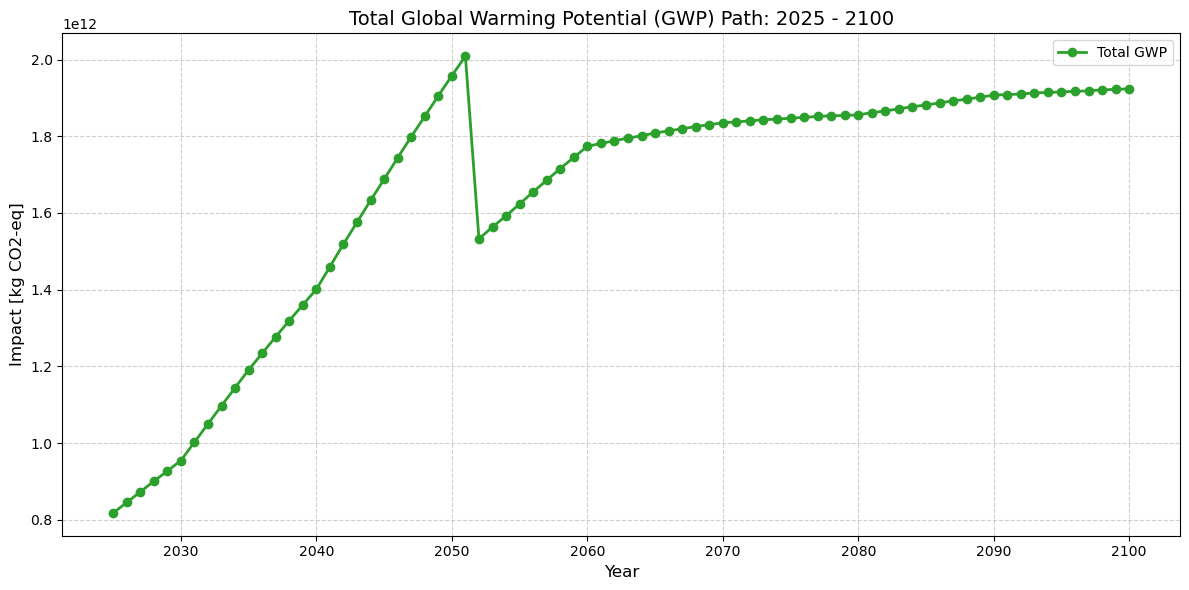

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the optimized scaling factors 's' from the model
# We create a dictionary where each key is a year and each value is the vector s_t
s_optimized = {}
for t in model.set_T:
    # Extract values for all process indices in set_C
    s_optimized[t] = np.array([model.s[c, t].value for c in model.set_C])

# 2. Calculate GWP for each year
gwp_history = []
years = sorted(list(model.set_T))

for t in years:
    # B matrix for the specific year
    B_t = B_meta[t] 
    
    # Calculate GWP coefficients for year t: (1 x R) @ (R x C) -> (1 x C)
    coef_gwp_t = C_gwp @ B_t
    
    # Calculate total GWP: Dot product of coefficients and scaling factors
    total_gwp_t = np.dot(coef_gwp_t, s_optimized[t])
    gwp_history.append(total_gwp_t)

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_history, marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('gwp_trend.png')
plt.show()

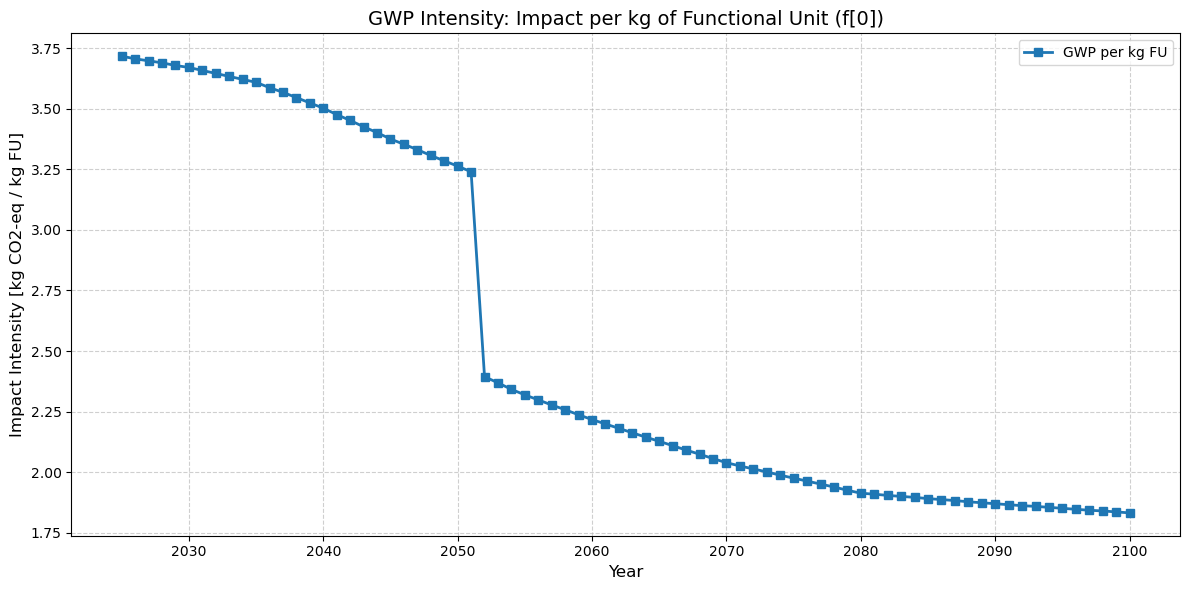

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity = [total / fu for total, fu in zip(gwp_history, fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')

# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('gwp_intensity_plot.png')
plt.show()

In [44]:
import numpy as np
import pandas as pd

# years in the model (sorted)
years = sorted(list(model.set_T))

# process names from A_design_final_df header row
# first two columns are empty -> process columns start at col index 2
process_names = A_design_final_df.iloc[0, 2:].astype(str).tolist()

# sanity check: number of processes matches
nC = len(list(model.set_C))
if len(process_names) != nC:
    raise ValueError(f"Mismatch: {len(process_names)} names in A_design_final_df header (from col 3 onward) vs {nC} processes in model.set_C")

# extract s into arrays (aligned with model.set_C order)
C_list = list(model.set_C)

s_optimized = {}
for t in years:
    s_optimized[t] = np.array([model.s[c, t].value for c in C_list], dtype=float)

top5_by_year = {}

for t in years:
    B_t = B_meta[t]                 # (R x C)
    coef_gwp_t = (C_gwp @ B_t)       # (C,) if C_gwp is (R,) or (1xR)

    coef_gwp_t = np.asarray(coef_gwp_t).reshape(-1)  # ensure 1D length C
    contrib = coef_gwp_t * s_optimized[t]            # (C,) per-process contribution

    df = pd.DataFrame({
        "process_index": np.arange(nC),
        "process_name": process_names,
        "coef_gwp": coef_gwp_t,
        "s": s_optimized[t],
        "gwp_contribution": contrib
    })

    # if you want to rank by magnitude (handles negatives), use abs
    # df["rank_metric"] = df["gwp_contribution"].abs()
    # top5 = df.nlargest(5, "rank_metric").drop(columns=["rank_metric"])

    # if you expect contributions should be positive and want "largest positive" only:
    top5 = df.nlargest(5, "gwp_contribution")

    top5_by_year[t] = top5.reset_index(drop=True)

# example: print one year
print(top5_by_year[2025][["process_index", "process_name", "gwp_contribution"]])

# optional: one combined table for all years
top5_all_years = pd.concat(
    [top5_by_year[t].assign(year=t) for t in years],
    ignore_index=True
)[["year", "process_index", "process_name", "gwp_contribution", "coef_gwp", "s"]]

top5_all_years.to_csv("top5_gwp_contributors_by_year.csv", index=False)


   process_index                                       process_name  \
0            543  Forest residue, processed and loaded, at landi...   
1            358                     Electricity, coal (life cycle)   
2            227                                  Heat, Natural Gas   
3            522         Plastic Incineration CO2 to the atmosphere   
4            541                Steam Cracker CO2 to the atmosphere   

   gwp_contribution  
0      2.465738e+12  
1      1.635473e+11  
2      1.344509e+11  
3      9.809496e+10  
4      9.570921e+10  


In [45]:
import numpy as np
import pandas as pd

years = sorted(list(model.set_T))

# names from A_design_final_df header row (skip first two empty columns)
process_names = A_design_final_df.iloc[0, 2:].astype(str).tolist()

C_list = list(model.set_C)
nC = len(C_list)

if len(process_names) != nC:
    raise ValueError(f"Mismatch: {len(process_names)} names (A_design_final_df row0, col>=2) vs {nC} processes in model.set_C")

# extract s vectors
s_optimized = {t: np.array([model.s[c, t].value for c in C_list], dtype=float) for t in years}

top5_by_year = {}

for t in years:
    B_t = B_meta[t]
    coef_gwp_t = np.asarray(C_gwp @ B_t).reshape(-1)  # length C

    contrib = coef_gwp_t * s_optimized[t]             # signed contribution per process

    df = pd.DataFrame({
        "process_index": np.arange(nC),
        "process_name": process_names,
        "coef_gwp": coef_gwp_t,
        "s": s_optimized[t],
        "gwp_contribution": contrib
    })

    df["abs_contribution"] = df["gwp_contribution"].abs()

    top5 = df.nlargest(5, "abs_contribution")[
        ["process_index", "process_name", "gwp_contribution", "abs_contribution", "coef_gwp", "s"]
    ].reset_index(drop=True)

    top5_by_year[t] = top5

# print a quick view (e.g., 2025)
print(top5_by_year[2025])

# optional: save all years to one CSV
top5_all_years = pd.concat(
    [top5_by_year[t].assign(year=t) for t in years],
    ignore_index=True
)[["year", "process_index", "process_name", "gwp_contribution", "abs_contribution", "coef_gwp", "s"]]

top5_all_years.to_csv("top5_gwp_contributors_by_year_abs_rank.csv", index=False)


   process_index                                       process_name  \
0            543  Forest residue, processed and loaded, at landi...   
1            358                     Electricity, coal (life cycle)   
2            227                                  Heat, Natural Gas   
3            522         Plastic Incineration CO2 to the atmosphere   
4            541                Steam Cracker CO2 to the atmosphere   

   gwp_contribution  abs_contribution     coef_gwp             s  
0      2.465738e+12      2.465738e+12  7008.968797  3.517976e+08  
1      1.635473e+11      1.635473e+11  1000.943000  1.633933e+08  
2      1.344509e+11      1.344509e+11     0.060200  2.233404e+12  
3      9.809496e+10      9.809496e+10     1.000000  9.809496e+10  
4      9.570921e+10      9.570921e+10     1.000000  9.570921e+10  


In [46]:
import numpy as np

years = sorted(list(model.set_T))
C_list = list(model.set_C)

for t in years[:5]:  # first few years
    B_t = B_meta[t]
    coef_gwp_t = np.asarray(C_gwp @ B_t).reshape(-1)

    s_t = np.array([model.s[c, t].value for c in C_list], dtype=float)

    total_dot = float(np.dot(coef_gwp_t, s_t))
    total_sum = float((coef_gwp_t * s_t).sum())

    print(t, total_dot, total_sum, "diff:", total_dot - total_sum)


2025 3281047796323.073 3281047796323.073 diff: 0.0
2026 3274372559681.2476 3274372559681.2476 diff: 0.0
2027 3282671516705.299 3282671516705.2983 diff: 0.00048828125
2028 3283742991007.202 3283742991007.2026 diff: -0.00048828125
2029 3256126863463.9097 3256126863463.909 diff: 0.00048828125


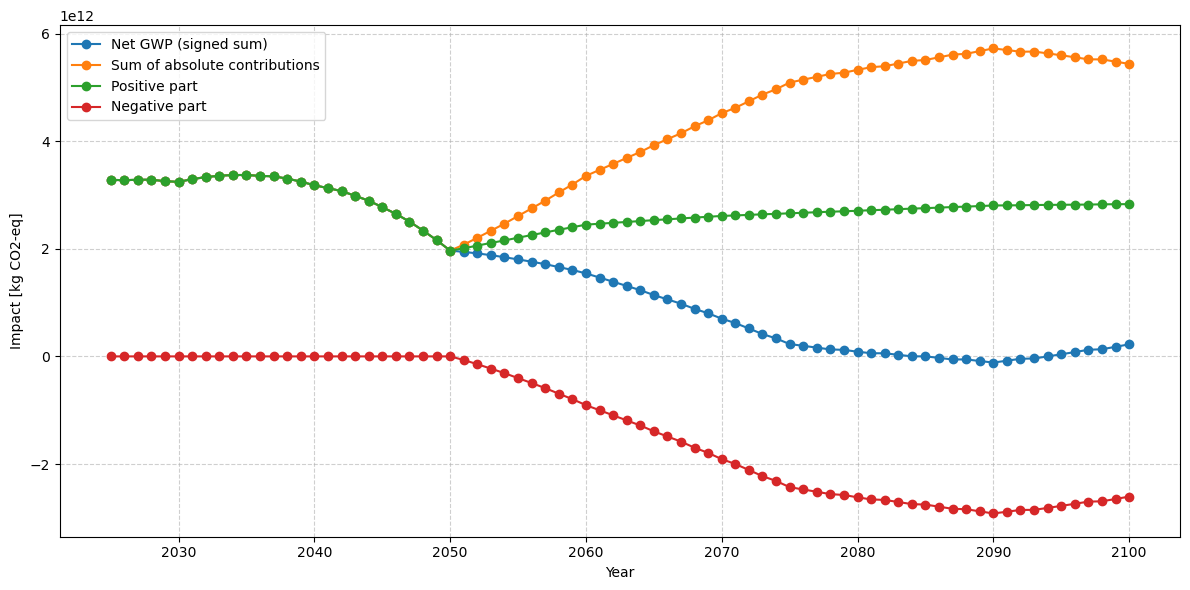

In [47]:
import numpy as np
import matplotlib.pyplot as plt

years = sorted(list(model.set_T))
C_list = list(model.set_C)

gwp_net = []
gwp_abs_total = []
gwp_pos = []
gwp_neg = []

for t in years:
    B_t = B_meta[t]
    coef_gwp_t = np.asarray(C_gwp @ B_t).reshape(-1)
    s_t = np.array([model.s[c, t].value for c in C_list], dtype=float)

    contrib = coef_gwp_t * s_t  # signed per-process contribution

    gwp_net.append(contrib.sum())
    gwp_abs_total.append(np.abs(contrib).sum())
    gwp_pos.append(contrib[contrib > 0].sum())
    gwp_neg.append(contrib[contrib < 0].sum())  # negative number

plt.figure(figsize=(12,6))
plt.plot(years, gwp_net, marker='o', label='Net GWP (signed sum)')
plt.plot(years, gwp_abs_total, marker='o', label='Sum of absolute contributions')
plt.plot(years, gwp_pos, marker='o', label='Positive part')
plt.plot(years, gwp_neg, marker='o', label='Negative part')
plt.xlabel('Year')
plt.ylabel('Impact [kg CO2-eq]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
import numpy as np
import pandas as pd
from pyomo.environ import value

years = sorted(list(model.set_T))

switchgrass = "Forest residue, processed and loaded, at landing system"
use_collect = "Use & Collection"

# ---- column names: row 0, from col 2 onward (since [0,0] and [0,1] are empty)
col_names = A_design_final_df.iloc[0, 2:].astype(str).tolist()
c_sw = col_names.index(switchgrass) + 1   # 1-based for model.set_C

# ---- row names: column 0, from row 2 onward (since [0,0] and [1,0] are empty)
row_names = A_design_final_df.iloc[2:, 0].astype(str).tolist()

def find_row_1based(label):
    if label not in row_names:
        # help you find exact spelling
        candidates = [x for x in row_names if label in x or x in label][:30]
        raise ValueError(f"Row label '{label}' not found in column 0 starting at row 2. Candidates: {candidates}")
    r0 = row_names.index(label)   # 0-based within the sliced list starting at df row 2
    return r0 + 1                 # because df row 2 corresponds to Pyomo row r=1 (A_init_rule uses r-1)

r_sw = find_row_1based(switchgrass)
r_uc = find_row_1based(use_collect)

rows = []
for t in years:
    A_sw = float(value(model.A[r_sw, c_sw, t]))
    s_sw = float(value(model.s[c_sw, t]))
    term = A_sw * s_sw

    f_uc = float(value(model.f[r_uc, t]))

    rows.append({
        "year": t,
        "A[switchgrass_row, switchgrass_col, t]": A_sw,
        "s[switchgrass_col, t]": s_sw,
        "A*s": term,
        "f[Use & Collection, t]": f_uc,
        "difference (A*s - f)": term - f_uc,
        "ratio (A*s)/f": (term / f_uc) if f_uc != 0 else np.nan
    })

df_cmp = pd.DataFrame(rows)
print(df_cmp.head(10))
df_cmp.to_csv("compare_switchgrass_selfterm_vs_f_use_collection.csv", index=False)

print("indices used -> r_sw:", r_sw, "c_sw:", c_sw, "r_uc:", r_uc)
print("A[r_sw,c_sw,2025] =", value(model.A[r_sw, c_sw, 2025]))
print("f[r_uc,2025]      =", value(model.f[r_uc, 2025]))


   year  A[switchgrass_row, switchgrass_col, t]  s[switchgrass_col, t]  \
0  2025                                  1000.0           3.517976e+08   
1  2026                                  1000.0           3.613893e+08   
2  2027                                  1000.0           3.740696e+08   
3  2028                                  1000.0           3.867499e+08   
4  2029                                  1000.0           3.958923e+08   
5  2030                                  1000.0           4.084603e+08   
6  2031                                  1000.0           4.304543e+08   
7  2032                                  1000.0           4.524484e+08   
8  2033                                  1000.0           4.744424e+08   
9  2034                                  1000.0           4.964364e+08   

            A*s  f[Use & Collection, t]  difference (A*s - f)  ratio (A*s)/f  
0  3.517976e+11            2.200000e+11          1.317976e+11       1.599080  
1  3.613893e+11            

In [43]:
import pandas as pd
from pyomo.environ import value

# 1. Load the CSV metadata (without assuming headers)
df_meta = pd.read_csv('results/A_design_final_df.csv', header=None, low_memory=False)

# 2. Extract Process Names from the first descriptive row
# We found "Use & Collection" is in Row 1, Column 2.
# This slice (from index 2 to the end) provides exactly 689 labels.
process_names = df_meta.iloc[1, 2:].tolist()

# 3. Extract solution values from the Pyomo model
# Dictionary keys: (column_index, year), values: optimized s
s_results = {
    (c, t): value(model.s[c, t]) 
    for c in model.set_C 
    for t in model.set_T
}

# 4. Create the DataFrame (Index: Years, Columns: Process Indices)
df_s = pd.Series(s_results).unstack(level=0)

# 5. Apply the labels
# df_s.columns initially contains 1, 2, ..., 689
# process_names contains "Use & Collection", "Pyrolysis...", etc.

if len(df_s.columns) == len(process_names):
    df_s.columns = process_names
    print("Success: Columns labeled correctly.")
else:
    print(f"Size Mismatch: Model has {len(df_s.columns)} vars, but found {len(process_names)} labels.")

# 6. Display the matrix
print("\nFinal Solution Matrix (Years x Processes):")
print(df_s.head())

# Optional: Export to CSV
df_s.to_csv("results/model_solutions_labeled.csv", index=False)

Success: Columns labeled correctly.

Final Solution Matrix (Years x Processes):
      Use & Collection  \
2025      2.200000e+11   
2026      2.280000e+11   
2027      2.360000e+11   
2028      2.440000e+11   
2029      2.520000e+11   

      Pyrolysis, LDPE Food Packaging Film (med-large format)  \
2025                                                0.0        
2026                                                0.0        
2027                                                0.0        
2028                                                0.0        
2029                                                0.0        

      Mechanical Recycling, LDPE Food Packaging Film (med-large format) (Flakes)  \
2025                                                0.0                            
2026                                                0.0                            
2027                                                0.0                            
2028                                      